# Runs all QM7 experiments with the full dataset!

## N.B this version: all tests were run for 20 repeats except Weave and Sm2Img (As htye were very very slow)

(Remember that the atomization energy is the energy required to form 1 mol of gaseous atoms from 1 mol of the molecule in its standard state under standard conditions)

QM& Regression, 7000ish compounds, Stratified split, MAE

Best conventionall KRR 10.22, best graph: ANI-1 2.86

This is a neater version of qm7_gnt_2

Use tdaf-tf2p7h2             C:\Users\ella_\.conda\envs\tdaf-tf2p7h2

In [1]:
import sys
sys.path.append(r"C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry")
sys.path.append(r"C:\Users\ella_\Documents\GitHub\icosahedron_projection")

import deepchem as dc
#from deepchem.feat import SmilesToImage

import tensorflow as tf
import os
import sys
import rdkit
import h5py
import helper_functions as h
import pandas

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.tri
import rdkit.Chem as Chem
import rdkit.Chem.AllChem as AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
import mpl_toolkits.mplot3d
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from collections import Counter

print("TensorFlow version: " + tf.__version__)

# topology stuff
from gtda.plotting import plot_point_cloud
from gtda.homology import VietorisRipsPersistence
from gtda.plotting import plot_diagram
from gtda.diagrams import PersistenceEntropy
from gtda.diagrams import NumberOfPoints
from gtda.diagrams import Amplitude
from sklearn.pipeline import make_union, Pipeline

# fixc this at some point
sys.path.append(r"C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry")
sys.path.append(r"C:\Users\ella_\Documents\GitHub\icosahedron_projection")

import projection
#from projection.molecule import Molecule
#from projection.pdbmolecule import PDBMolecule
#from projection.mol2molecule import Mol2Molecule

import helper_functions as h
loaders, classification_datasets, regression_datasets, metric_types = h.deepchem_dataset_dictionaries()

# change THIS

dataset_name='qm7'

data_dir=r'F:\Nextcloud\science\Datasets\topol_datasets'
results_dir=r"F:\Nextcloud\science\results\topology_and_graphs\d_" + dataset_name
test_file=dataset_name + '.csv'
data_file_name=dataset_name + '_topological_features.hdf5'
loader = loaders[dataset_name]
make_dataset=False # whether to recalc the dataset

print(f"DeepChem version: {dc.__version__}")

############################### settings for all experiments #################

best_con = 123.7 #multitask value   #10.22
best_graph = 8.8 # for dtnn, didn't run ani#2.86

num_repeats= 5
num_epochs = 500

metric_labels=['mean_squared_error','pearson_r2_score',
               'mae_score', 'rmse']


metric1 = dc.metrics.Metric(dc.metrics.mean_squared_error)
metric2 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
metric3 = dc.metrics.Metric(dc.metrics.mae_score)
metrics = [metric1, metric2, metric3]
selected_metric = 2 #which metric to use for callback

Splitter = dc.splits.SingletaskStratifiedSplitter()

split_fraction=[0.1, 0.1, 0.8]


KeyboardInterrupt: 

In [2]:
hdf5_file_name='qm7_topological_features.hdf5'
fh = h5py.File(os.path.join(data_dir,hdf5_file_name), 'r+')
num_of_rows, num_of_molecules = h.basic_info_hdf5_dataset(fh, label='molID')

num_of_ rows is:	6838
num_of_molecules is:	 128
MolID: count
Counter({127: 6711, 0: 1, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1, 8: 1, 9: 1, 10: 1, 11: 1, 12: 1, 13: 1, 14: 1, 15: 1, 16: 1, 17: 1, 18: 1, 19: 1, 20: 1, 21: 1, 22: 1, 23: 1, 24: 1, 25: 1, 26: 1, 27: 1, 28: 1, 29: 1, 30: 1, 31: 1, 32: 1, 33: 1, 34: 1, 35: 1, 36: 1, 37: 1, 38: 1, 39: 1, 40: 1, 41: 1, 42: 1, 43: 1, 44: 1, 45: 1, 46: 1, 47: 1, 48: 1, 49: 1, 50: 1, 51: 1, 52: 1, 53: 1, 54: 1, 55: 1, 56: 1, 57: 1, 58: 1, 59: 1, 60: 1, 61: 1, 62: 1, 63: 1, 64: 1, 65: 1, 66: 1, 67: 1, 68: 1, 69: 1, 70: 1, 71: 1, 72: 1, 73: 1, 74: 1, 75: 1, 76: 1, 77: 1, 78: 1, 79: 1, 80: 1, 81: 1, 82: 1, 83: 1, 84: 1, 85: 1, 86: 1, 87: 1, 88: 1, 89: 1, 90: 1, 91: 1, 92: 1, 93: 1, 94: 1, 95: 1, 96: 1, 97: 1, 98: 1, 99: 1, 100: 1, 101: 1, 102: 1, 103: 1, 104: 1, 105: 1, 106: 1, 107: 1, 108: 1, 109: 1, 110: 1, 111: 1, 112: 1, 113: 1, 114: 1, 115: 1, 116: 1, 117: 1, 118: 1, 119: 1, 120: 1, 121: 1, 122: 1, 123: 1, 124: 1, 125: 1, 126: 1})


In [3]:
fh.keys()

<KeysViewHDF5 ['PCA_1', 'PCA_10', 'PCA_11', 'PCA_12', 'PCA_13', 'PCA_14', 'PCA_15', 'PCA_16', 'PCA_17', 'PCA_18', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'PCA_6', 'PCA_7', 'PCA_8', 'PCA_9', 'SMILES', 'bottle_1', 'bottle_2', 'bottle_3', 'landsc_1', 'landsc_2', 'landsc_3', 'molID', 'no_p_1', 'no_p_2', 'no_p_3', 'pers_S_1', 'pers_S_2', 'pers_S_3', 'pers_img_1', 'pers_img_2', 'pers_img_3', 'u0_atom', 'u0_atom_norm', 'wasser_1', 'wasser_2', 'wasser_3']>

In [4]:
fh['u0_atom'][:]

array([ -417.96,  -712.42,  -564.21, ..., -1523.  , -1778.6 , -1531.9 ],
      dtype=float32)

In [5]:
feature_name_list = ['pers_S_1', 'pers_S_2', 'pers_S_3',
                    'no_p_1', 'no_p_2', 'no_p_3',
                    'bottle_1', 'bottle_2', 'bottle_3',
                    'wasser_1', 'wasser_2', 'wasser_3',
                    'landsc_1', 'landsc_2', 'landsc_3',
                    'pers_img_1', 'pers_img_2', 'pers_img_3']

PCA_list = ['PCA_1', 'PCA_2', 'PCA_3',
           'PCA_4', 'PCA_5', 'PCA_6',
           'PCA_7', 'PCA_8', 'PCA_9',
           'PCA_10', 'PCA_11', 'PCA_12',
           'PCA_13', 'PCA_14', 'PCA_15',
           'PCA_16', 'PCA_17', 'PCA_18']

task_list = ['u0_atom']

## Functions

In [6]:
metric_labels

['mean_squared_error', 'pearson_r2_score', 'mae_score', 'rmse']

# Load data


## Create topological datasets

We use Numpy datasets to create the two toplogical datasets and two transformers (used as the controls use them and they are supposed to improve training). The topological dataset is normalised in X and y, PCA is only normalised in y as PCA is a normalisation.

This sorts out the datasets, transformers and splitters for the task

In [7]:
fh['SMILES']

<HDF5 dataset "SMILES": shape (6838,), type "|O">

In [8]:
## loading data from the hdf5 file
X_data = h.load_all_hdf5(
    fh,
    num_of_rows, 
    column_headers=feature_name_list)

PCA_X_data = h.load_all_hdf5(
    fh,
    num_of_rows, 
    column_headers=PCA_list)

y_data = h.load_all_hdf5(
    fh,
    num_of_rows, 
    column_headers=task_list)

SMILES_list = np.array(fh['SMILES'])

# making the datasets
topol_dataset = dc.data.DiskDataset.from_numpy(
    X_data, 
    y_data, 
    ids=SMILES_list)

pca_dataset = dc.data.DiskDataset.from_numpy(
    PCA_X_data, 
    y_data, 
    ids=SMILES_list)

# setting up the splitters for the task
Splitter_Object_tf = dc.splits.SingletaskStratifiedSplitter()
Splitter_Object_pca = dc.splits.SingletaskStratifiedSplitter()

# doing a transform on the data to make it easier for hte NN
# both y and x
transformers_tf = [
    dc.trans.NormalizationTransformer(
        transform_X=True, 
        dataset=topol_dataset),
    dc.trans.NormalizationTransformer(
        transform_y=True, 
        dataset=topol_dataset)]
# only y
transformers_pca = [
    dc.trans.NormalizationTransformer(
        transform_y=True, 
        dataset=pca_dataset)]



C:\Users\ella_\.conda\envs\tdaf-tf2p7h2\lib\site-packages\numpy\lib\format.py:363: UserWarning: metadata on a dtype may be saved or ignored, but will raise if saved when read. Use another form of storage.
  d['descr'] = dtype_to_descr(array.dtype)


Text(0, 0.5, 'No.')

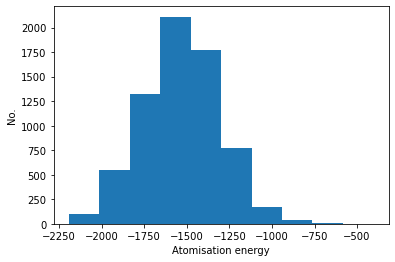

In [9]:
plt.hist(y_data)
plt.xlabel('Atomisation energy')
plt.ylabel("No.")

# Training on the topological features

#### Topological features

In [10]:
%%time
output_metrics_tf=h.topol_regression_experiment(
    dataset=topol_dataset,
    transformers=transformers_tf,
    Splitter_Object=Splitter_Object_tf,
    tasks=task_list,
    metrics=metrics,
    metric_selector=selected_metric,
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_fraction=split_fraction,
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score', 
                   'mae_score', 
                   'rmse']
    )
output_metrics_tf

Metric selected is mae_score
Training with 683 points
Validation with 683 points
Testing with 5464 points
Total dataset size: 6830
Step 15 validation: mae_score=0.785055
Step 30 validation: mae_score=0.76034
Step 45 validation: mae_score=0.771783
Step 60 validation: mae_score=0.775416
Step 75 validation: mae_score=0.772941
Step 90 validation: mae_score=0.798779
Step 105 validation: mae_score=0.790593
Step 120 validation: mae_score=0.764208
Step 135 validation: mae_score=0.76578
Step 150 validation: mae_score=0.759471
Step 165 validation: mae_score=0.761857
Step 180 validation: mae_score=0.762547
Step 195 validation: mae_score=0.758596
Step 210 validation: mae_score=0.768569
Step 225 validation: mae_score=0.760733
Step 240 validation: mae_score=0.764058
Step 255 validation: mae_score=0.826327
Step 270 validation: mae_score=0.770457
Step 285 validation: mae_score=0.764858
Step 300 validation: mae_score=0.758926
Step 315 validation: mae_score=0.760244
Step 330 validation: mae_score=0.7601

Step 3015 validation: mae_score=0.756507
Step 3030 validation: mae_score=0.757537
Step 3045 validation: mae_score=0.756434
Step 3060 validation: mae_score=0.754911
Step 3075 validation: mae_score=0.773886
Step 3090 validation: mae_score=0.755195
Step 3105 validation: mae_score=0.754037
Step 3120 validation: mae_score=0.754615
Step 3135 validation: mae_score=0.781069
Step 3150 validation: mae_score=0.772034
Step 3165 validation: mae_score=0.776841
Step 3180 validation: mae_score=0.78534
Step 3195 validation: mae_score=0.766467
Step 3210 validation: mae_score=0.753844
Step 3225 validation: mae_score=0.768776
Step 3240 validation: mae_score=0.754448
Step 3255 validation: mae_score=0.781444
Step 3270 validation: mae_score=0.761357
Step 3285 validation: mae_score=0.783746
Step 3300 validation: mae_score=0.761758
Step 3315 validation: mae_score=0.755216
Step 3330 validation: mae_score=0.761697
Step 3345 validation: mae_score=0.766683
Step 3360 validation: mae_score=0.7556
Step 3375 validatio

C:\Users\ella_\.conda\envs\tdaf-tf2p7h2\lib\site-packages\numpy\lib\format.py:363: UserWarning: metadata on a dtype may be saved or ignored, but will raise if saved when read. Use another form of storage.
  d['descr'] = dtype_to_descr(array.dtype)


Training with 683 points
Validation with 683 points
Testing with 5464 points
Total dataset size: 6830
Step 15 validation: mae_score=0.785367
Step 30 validation: mae_score=0.786157
Step 45 validation: mae_score=0.783949
Step 60 validation: mae_score=0.773442
Step 75 validation: mae_score=0.773428
Step 90 validation: mae_score=0.7705
Step 105 validation: mae_score=0.775905
Step 120 validation: mae_score=0.773527
Step 135 validation: mae_score=0.770274
Step 150 validation: mae_score=0.775804
Step 165 validation: mae_score=0.770146
Step 180 validation: mae_score=0.771654
Step 195 validation: mae_score=0.772209
Step 210 validation: mae_score=0.768733
Step 225 validation: mae_score=0.767709
Step 240 validation: mae_score=0.779425
Step 255 validation: mae_score=0.775753
Step 270 validation: mae_score=0.805375
Step 285 validation: mae_score=0.77795
Step 300 validation: mae_score=0.77545
Step 315 validation: mae_score=0.771311
Step 330 validation: mae_score=0.767626
Step 345 validation: mae_sco

Step 3045 validation: mae_score=0.774741
Step 3060 validation: mae_score=0.773823
Step 3075 validation: mae_score=0.770587
Step 3090 validation: mae_score=0.770229
Step 3105 validation: mae_score=0.768283
Step 3120 validation: mae_score=0.769133
Step 3135 validation: mae_score=0.787208
Step 3150 validation: mae_score=0.77391
Step 3165 validation: mae_score=0.801765
Step 3180 validation: mae_score=0.791112
Step 3195 validation: mae_score=0.770334
Step 3210 validation: mae_score=0.768595
Step 3225 validation: mae_score=0.776805
Step 3240 validation: mae_score=0.770627
Step 3255 validation: mae_score=0.767375
Step 3270 validation: mae_score=0.78362
Step 3285 validation: mae_score=0.766348
Step 3300 validation: mae_score=0.780422
Step 3315 validation: mae_score=0.769839
Step 3330 validation: mae_score=0.772756
Step 3345 validation: mae_score=0.7726
Step 3360 validation: mae_score=0.769562
Step 3375 validation: mae_score=0.770433
Step 3390 validation: mae_score=0.768656
Step 3405 validation

...

Step 3075 validation: mae_score=0.764148
Step 3090 validation: mae_score=0.765996
Step 3105 validation: mae_score=0.767504
Step 3120 validation: mae_score=0.764842
Step 3135 validation: mae_score=0.765557
Step 3150 validation: mae_score=0.765969
Step 3165 validation: mae_score=0.767485
Step 3180 validation: mae_score=0.768972
Step 3195 validation: mae_score=0.765806
Step 3210 validation: mae_score=0.772579
Step 3225 validation: mae_score=0.764787
Step 3240 validation: mae_score=0.766216
Step 3255 validation: mae_score=0.769745
Step 3270 validation: mae_score=0.764941
Step 3285 validation: mae_score=0.766117
Step 3300 validation: mae_score=0.76463
Step 3315 validation: mae_score=0.768831
Step 3330 validation: mae_score=0.772003
Step 3345 validation: mae_score=0.773933
Step 3360 validation: mae_score=0.766282
Step 3375 validation: mae_score=0.766072
Step 3390 validation: mae_score=0.768326
Step 3405 validation: mae_score=0.763967
Step 3420 validation: mae_score=0.769074
Step 3435 validat

C:\Users\ella_\.conda\envs\tdaf-tf2p7h2\lib\site-packages\numpy\lib\format.py:363: UserWarning: metadata on a dtype may be saved or ignored, but will raise if saved when read. Use another form of storage.
  d['descr'] = dtype_to_descr(array.dtype)


Training with 683 points
Validation with 683 points
Testing with 5464 points
Total dataset size: 6830
Step 15 validation: mae_score=0.832685
Step 30 validation: mae_score=0.799742
Step 45 validation: mae_score=0.84583
Step 60 validation: mae_score=0.816896
Step 75 validation: mae_score=0.794774
Step 90 validation: mae_score=0.801268
Step 105 validation: mae_score=0.796515
Step 120 validation: mae_score=0.796676
Step 135 validation: mae_score=0.807028
Step 150 validation: mae_score=0.793589
Step 165 validation: mae_score=0.794749
Step 180 validation: mae_score=0.80529
Step 195 validation: mae_score=0.801004
Step 210 validation: mae_score=0.801817
Step 225 validation: mae_score=0.830992
Step 240 validation: mae_score=0.796
Step 255 validation: mae_score=0.796542
Step 270 validation: mae_score=0.798737
Step 285 validation: mae_score=0.796754
Step 300 validation: mae_score=0.791431
Step 315 validation: mae_score=0.794293
Step 330 validation: mae_score=0.797506
Step 345 validation: mae_scor

Step 3015 validation: mae_score=0.795446
Step 3030 validation: mae_score=0.795949
Step 3045 validation: mae_score=0.79335
Step 3060 validation: mae_score=0.791119
Step 3075 validation: mae_score=0.794395
Step 3090 validation: mae_score=0.792259
Step 3105 validation: mae_score=0.791807
Step 3120 validation: mae_score=0.791669
Step 3135 validation: mae_score=0.795268
Step 3150 validation: mae_score=0.796769
Step 3165 validation: mae_score=0.794036
Step 3180 validation: mae_score=0.790954
Step 3195 validation: mae_score=0.79106
Step 3210 validation: mae_score=0.839863
Step 3225 validation: mae_score=0.79253
Step 3240 validation: mae_score=0.791409
Step 3255 validation: mae_score=0.791922
Step 3270 validation: mae_score=0.796255
Step 3285 validation: mae_score=0.789419
Step 3300 validation: mae_score=0.80506
Step 3315 validation: mae_score=0.794835
Step 3330 validation: mae_score=0.790974
Step 3345 validation: mae_score=0.800849
Step 3360 validation: mae_score=0.803152
Step 3375 validation

,tr_mse,tr_r2,tr_mae,tr_rmse,val_mse,val_r2,val_mae,val_rmse,te_mse,te_r2,te_mae,te_rmse
0,46542.058066,0.086231,172.813820,215.736084,45624.603452,0.102996,171.908993,213.599165,47802.191127,0.058494,173.156561,218.637122
1,41874.713349,0.152552,165.060826,204.633119,46188.147195,0.068011,171.696448,214.914279,48650.934107,0.059569,170.749776,220.569568
2,44320.859136,0.096872,168.926678,210.525198,51822.580302,0.032636,171.233392,227.645734,59406.076207,0.020723,172.025971,243.733617
3,44127.315336,0.092758,165.969770,210.065026,43699.865088,0.097954,168.923329,209.045127,45849.092247,0.063348,169.661592,214.124011
4,43630.745684,0.128531,166.669774,208.879740,47891.616175,0.068010,175.841717,218.841532,50560.187845,0.044209,175.349928,224.855927
5,44406.788267,0.089247,168.341697,210.729182,44475.703838,0.086229,167.646209,210.892636,48606.867770,0.045812,170.746132,220.469653
6,44150.819547,0.100555,166.905555,210.120964,51518.115297,0.025063,176.039359,226.976024,49713.090228,0.040845,170.555094,222.964325
7,43852.521835,0.106904,166.183535,209.409937,45752.363603,0.073591,170.200953,213.898022,45389.788850,0.079518,170.557246,213.048795
8,43136.700143,0.110415,165.648222,207.693765,43078.526474,0.117169,165.989439,207.553671,49005.904709,0.035778,171.033476,221.372773
9,43026.532700,0.123763,164.324103,207.428380,45494.492872,0.073197,170.453731,213.294381,60623.543034,0.023557,172.835132,246.218486


#### PCA of topological features

In [11]:
%%time
output_metrics_pca=h.topol_regression_experiment(
    dataset=pca_dataset,
    transformers=transformers_pca,
    Splitter_Object=Splitter_Object_pca,
    tasks=task_list,
    metrics=metrics,
    metric_selector=selected_metric,
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_fraction=split_fraction,
    patience=15,
    metric_labels=['mean_squared_error',
                'pearson_r2_score', 
                'mae_score', 
                'rmse']
    )
output_metrics_pca

Metric selected is mae_score


C:\Users\ella_\.conda\envs\tdaf-tf2p7h2\lib\site-packages\numpy\lib\format.py:363: UserWarning: metadata on a dtype may be saved or ignored, but will raise if saved when read. Use another form of storage.
  d['descr'] = dtype_to_descr(array.dtype)


Training with 683 points
Validation with 683 points
Testing with 5464 points
Total dataset size: 6830
Step 15 validation: mae_score=0.776393
Step 30 validation: mae_score=0.773457
Step 45 validation: mae_score=0.773844
Step 60 validation: mae_score=0.776756
Step 75 validation: mae_score=0.773278
Step 90 validation: mae_score=0.780113
Step 105 validation: mae_score=0.789287
Step 120 validation: mae_score=0.771233
Step 135 validation: mae_score=0.772673
Step 150 validation: mae_score=0.767954
Step 165 validation: mae_score=0.771562
Step 180 validation: mae_score=0.783405
Step 195 validation: mae_score=0.770979
Step 210 validation: mae_score=0.775309
Step 225 validation: mae_score=0.780565
Step 240 validation: mae_score=0.780429
Step 255 validation: mae_score=0.784576
Step 270 validation: mae_score=0.767764
Step 285 validation: mae_score=0.78436
Step 300 validation: mae_score=0.791011
Step 315 validation: mae_score=0.770743
Step 330 validation: mae_score=0.789401
Step 345 validation: mae_

Step 3030 validation: mae_score=0.789372
Step 3045 validation: mae_score=0.78425
Step 3060 validation: mae_score=0.770517
Step 3075 validation: mae_score=0.773849
Step 3090 validation: mae_score=0.777886
Step 3105 validation: mae_score=0.769607
Step 3120 validation: mae_score=0.768977
Step 3135 validation: mae_score=0.767887
Step 3150 validation: mae_score=0.773842
Step 3165 validation: mae_score=0.787927
Step 3180 validation: mae_score=0.769488
Step 3195 validation: mae_score=0.773888
Step 3210 validation: mae_score=0.779399
Step 3225 validation: mae_score=0.770824
Step 3240 validation: mae_score=0.778781
Step 3255 validation: mae_score=0.778557
Step 3270 validation: mae_score=0.780867
Step 3285 validation: mae_score=0.772086
Step 3300 validation: mae_score=0.779252
Step 3315 validation: mae_score=0.769601
Step 3330 validation: mae_score=0.769338
Step 3345 validation: mae_score=0.771959
Step 3360 validation: mae_score=0.77414
Step 3375 validation: mae_score=0.767794
Step 3390 validati

C:\Users\ella_\.conda\envs\tdaf-tf2p7h2\lib\site-packages\numpy\lib\format.py:363: UserWarning: metadata on a dtype may be saved or ignored, but will raise if saved when read. Use another form of storage.
  d['descr'] = dtype_to_descr(array.dtype)


...

Step 3045 validation: mae_score=0.786248
Step 3060 validation: mae_score=0.788071
Step 3075 validation: mae_score=0.800291
Step 3090 validation: mae_score=0.795508
Step 3105 validation: mae_score=0.782768
Step 3120 validation: mae_score=0.783661
Step 3135 validation: mae_score=0.785525
Step 3150 validation: mae_score=0.78273
Step 3165 validation: mae_score=0.791106
Step 3180 validation: mae_score=0.784177
Step 3195 validation: mae_score=0.782291
Step 3210 validation: mae_score=0.790963
Step 3225 validation: mae_score=0.792614
Step 3240 validation: mae_score=0.79017
Step 3255 validation: mae_score=0.865522
Step 3270 validation: mae_score=0.799465
Step 3285 validation: mae_score=0.811498
Step 3300 validation: mae_score=0.792255
Step 3315 validation: mae_score=0.786311
Step 3330 validation: mae_score=0.802333
Step 3345 validation: mae_score=0.791984
Step 3360 validation: mae_score=0.803906
Step 3375 validation: mae_score=0.784185
Step 3390 validation: mae_score=0.790145
Step 3405 validati

C:\Users\ella_\.conda\envs\tdaf-tf2p7h2\lib\site-packages\numpy\lib\format.py:363: UserWarning: metadata on a dtype may be saved or ignored, but will raise if saved when read. Use another form of storage.
  d['descr'] = dtype_to_descr(array.dtype)


Training with 683 points
Validation with 683 points
Testing with 5464 points
Total dataset size: 6830
Step 15 validation: mae_score=0.90709
Step 30 validation: mae_score=0.809967
Step 45 validation: mae_score=0.771629
Step 60 validation: mae_score=0.776847
Step 75 validation: mae_score=0.764598
Step 90 validation: mae_score=0.777636
Step 105 validation: mae_score=0.782094
Step 120 validation: mae_score=0.768251
Step 135 validation: mae_score=0.792415
Step 150 validation: mae_score=0.769562
Step 165 validation: mae_score=0.767036
Step 180 validation: mae_score=0.77061
Step 195 validation: mae_score=0.763737
Step 210 validation: mae_score=0.770252
Step 225 validation: mae_score=0.764094
Step 240 validation: mae_score=0.765008
Step 255 validation: mae_score=0.769631
Step 270 validation: mae_score=0.773778
Step 285 validation: mae_score=0.778822
Step 300 validation: mae_score=0.766963
Step 315 validation: mae_score=0.7752
Step 330 validation: mae_score=0.771782
Step 345 validation: mae_sco

Step 3015 validation: mae_score=0.774448
Step 3030 validation: mae_score=0.790288
Step 3045 validation: mae_score=0.773093
Step 3060 validation: mae_score=0.768726
Step 3075 validation: mae_score=0.778809
Step 3090 validation: mae_score=0.775676
Step 3105 validation: mae_score=0.777996
Step 3120 validation: mae_score=0.775454
Step 3135 validation: mae_score=0.761582
Step 3150 validation: mae_score=0.784688
Step 3165 validation: mae_score=0.784934
Step 3180 validation: mae_score=0.782616
Step 3195 validation: mae_score=0.760835
Step 3210 validation: mae_score=0.758917
Step 3225 validation: mae_score=0.766442
Step 3240 validation: mae_score=0.771646
Step 3255 validation: mae_score=0.772294
Step 3270 validation: mae_score=0.767419
Step 3285 validation: mae_score=0.774167
Step 3300 validation: mae_score=0.760646
Step 3315 validation: mae_score=0.768674
Step 3330 validation: mae_score=0.754243
Step 3345 validation: mae_score=0.77193
Step 3360 validation: mae_score=0.800867
Step 3375 validat

,tr_mse,tr_r2,tr_mae,tr_rmse,val_mse,val_r2,val_mae,val_rmse,te_mse,te_r2,te_mae,te_rmse
0,43665.868246,0.128185,167.906956,208.963796,47145.651454,0.062386,174.779650,217.130494,104692.274550,0.005929,179.138708,323.561856
1,48633.100830,0.097401,175.639898,220.529138,48755.525773,0.067232,176.173226,220.806535,57643.331308,0.025386,180.250911,240.090257
2,43198.842258,0.113420,167.456277,207.843312,43978.332894,0.097357,168.323580,209.710116,57099.289098,0.022373,172.052415,238.954575
3,46206.970644,0.061144,170.400294,214.958067,44491.172589,0.083939,168.729798,210.929307,44739.644027,0.079812,168.982679,211.517479
4,43670.128295,0.101121,166.191751,208.973990,46280.415291,0.058620,171.339704,215.128834,44861.242503,0.076670,169.433369,211.804727
5,41943.205649,0.143033,163.079094,204.800404,45349.514341,0.076038,170.691386,212.954254,48654.990203,0.051702,172.152726,220.578762
6,43029.024779,0.122854,167.550489,207.434387,43790.855433,0.118107,169.168205,209.262647,48124.019672,0.054152,171.356134,219.371875
7,42282.617222,0.135337,163.408132,205.627375,44322.691765,0.092844,169.631643,210.529551,205743.487115,0.002774,177.515265,453.589558
8,41862.519767,0.148083,166.479486,204.603323,46582.295711,0.058776,172.623061,215.829321,50772.378430,0.036878,172.964610,225.327270
9,47236.089035,0.138077,174.476918,217.338651,50387.667909,0.071785,179.641449,224.471976,58671.327515,0.033756,181.100039,242.221650


#### PCA of topological features with no transform

In [12]:
%%time
output_metrics_pca_no_transform=h.no_transform_topol_regression_experiment(
    dataset=pca_dataset,
    Splitter_Object=Splitter_Object_pca,
    tasks=task_list,
    metrics=metrics,
    metric_selector=selected_metric,
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_fraction=split_fraction,
    patience=15,
    metric_labels=['mean_squared_error',
                'pearson_r2_score', 
                'mae_score', 
                'rmse']
    )
output_metrics_pca_no_transform

Metric selected is mae_score
Training with 683 points


C:\Users\ella_\.conda\envs\tdaf-tf2p7h2\lib\site-packages\numpy\lib\format.py:363: UserWarning: metadata on a dtype may be saved or ignored, but will raise if saved when read. Use another form of storage.
  d['descr'] = dtype_to_descr(array.dtype)


Validation with 683 points
Testing with 5464 points
Total dataset size: 6830
Step 15 validation: mae_score=1518.52
Step 30 validation: mae_score=1502.73
Step 45 validation: mae_score=1485.99
Step 60 validation: mae_score=1467.85
Step 75 validation: mae_score=1448.13
Step 90 validation: mae_score=1426.67
Step 105 validation: mae_score=1403.51
Step 120 validation: mae_score=1378.59
Step 135 validation: mae_score=1352.14
Step 150 validation: mae_score=1325.8
Step 165 validation: mae_score=1300.07
Step 180 validation: mae_score=1273.96
Step 195 validation: mae_score=1248.12
Step 210 validation: mae_score=1222.31
Step 225 validation: mae_score=1197.81
Step 240 validation: mae_score=1172.39
Step 255 validation: mae_score=1147.67
Step 270 validation: mae_score=1122.53
Step 285 validation: mae_score=1097.92
Step 300 validation: mae_score=1073.97
Step 315 validation: mae_score=1048.92
Step 330 validation: mae_score=1024.21
Step 345 validation: mae_score=999.057
Step 360 validation: mae_score=97

Step 3120 validation: mae_score=171.624
Step 3135 validation: mae_score=171.78
Step 3150 validation: mae_score=171.553
Step 3165 validation: mae_score=171.419
Step 3180 validation: mae_score=171.531
Step 3195 validation: mae_score=171.258
Step 3210 validation: mae_score=171.632
Step 3225 validation: mae_score=171.408
Step 3240 validation: mae_score=171.278
Step 3255 validation: mae_score=171.394
Step 3270 validation: mae_score=170.95
Step 3285 validation: mae_score=171.245
Step 3300 validation: mae_score=171.733
Step 3315 validation: mae_score=171.294
Step 3330 validation: mae_score=171.377
Step 3345 validation: mae_score=171.558
Step 3360 validation: mae_score=171.319
Step 3375 validation: mae_score=171.551
Step 3390 validation: mae_score=171.262
Step 3405 validation: mae_score=170.801
Step 3420 validation: mae_score=171.205
Step 3435 validation: mae_score=171.105
Step 3450 validation: mae_score=170.899
Step 3465 validation: mae_score=170.85
Step 3480 validation: mae_score=170.853
Ste

C:\Users\ella_\.conda\envs\tdaf-tf2p7h2\lib\site-packages\numpy\lib\format.py:363: UserWarning: metadata on a dtype may be saved or ignored, but will raise if saved when read. Use another form of storage.
  d['descr'] = dtype_to_descr(array.dtype)


...

Step 3105 validation: mae_score=175.076
Step 3120 validation: mae_score=175.044
Step 3135 validation: mae_score=174.85
Step 3150 validation: mae_score=174.566
Step 3165 validation: mae_score=175.168
Step 3180 validation: mae_score=174.535
Step 3195 validation: mae_score=174.734
Step 3210 validation: mae_score=175.002
Step 3225 validation: mae_score=174.932
Step 3240 validation: mae_score=174.667
Step 3255 validation: mae_score=174.511
Step 3270 validation: mae_score=174.558
Step 3285 validation: mae_score=174.502
Step 3300 validation: mae_score=174.093
Step 3315 validation: mae_score=173.963
Step 3330 validation: mae_score=174.116
Step 3345 validation: mae_score=173.888
Step 3360 validation: mae_score=174.229
Step 3375 validation: mae_score=174.561
Step 3390 validation: mae_score=174.293
Step 3405 validation: mae_score=174.019
Step 3420 validation: mae_score=174.393
Step 3435 validation: mae_score=174.075
Step 3450 validation: mae_score=173.654
Step 3465 validation: mae_score=173.735
S

C:\Users\ella_\.conda\envs\tdaf-tf2p7h2\lib\site-packages\numpy\lib\format.py:363: UserWarning: metadata on a dtype may be saved or ignored, but will raise if saved when read. Use another form of storage.
  d['descr'] = dtype_to_descr(array.dtype)


Training with 683 points
Validation with 683 points
Testing with 5464 points
Total dataset size: 6830
Step 15 validation: mae_score=1517.62
Step 30 validation: mae_score=1501.33
Step 45 validation: mae_score=1484.04
Step 60 validation: mae_score=1465.63
Step 75 validation: mae_score=1445.56
Step 90 validation: mae_score=1423.33
Step 105 validation: mae_score=1401.23
Step 120 validation: mae_score=1378.59
Step 135 validation: mae_score=1356.14
Step 150 validation: mae_score=1333.56
Step 165 validation: mae_score=1310.06
Step 180 validation: mae_score=1286.27
Step 195 validation: mae_score=1261.01
Step 210 validation: mae_score=1235.14
Step 225 validation: mae_score=1209.39
Step 240 validation: mae_score=1181.75
Step 255 validation: mae_score=1153.96
Step 270 validation: mae_score=1124.86
Step 285 validation: mae_score=1095.9
Step 300 validation: mae_score=1065.38
Step 315 validation: mae_score=1034.13
Step 330 validation: mae_score=1002.67
Step 345 validation: mae_score=971.184
Step 360

Step 3105 validation: mae_score=200.797
Step 3120 validation: mae_score=200.456
Step 3135 validation: mae_score=200.188
Step 3150 validation: mae_score=199.572
Step 3165 validation: mae_score=200.595
Step 3180 validation: mae_score=200.878
Step 3195 validation: mae_score=200.441
Step 3210 validation: mae_score=199.434
Step 3225 validation: mae_score=200.411
Step 3240 validation: mae_score=200.387
Step 3255 validation: mae_score=199.874
Step 3270 validation: mae_score=198.726
Step 3285 validation: mae_score=198.748
Step 3300 validation: mae_score=198.635
Step 3315 validation: mae_score=199.499
Step 3330 validation: mae_score=199.958
Step 3345 validation: mae_score=200.551
Step 3360 validation: mae_score=198.194
Step 3375 validation: mae_score=199.009
Step 3390 validation: mae_score=198.782
Step 3405 validation: mae_score=199.339
Step 3420 validation: mae_score=198.991
Step 3435 validation: mae_score=199.327
Step 3450 validation: mae_score=199.561
Step 3465 validation: mae_score=198.983


,tr_mse,tr_r2,tr_mae,tr_rmse,val_mse,val_r2,val_mae,val_rmse,te_mse,te_r2,te_mae,te_rmse
0,42506.794500,0.123534,165.881264,206.171760,45237.235079,0.076112,170.717970,212.690468,6.231846e+04,0.016149,173.008799,249.636662
1,47306.301506,0.071607,172.612532,217.500118,49867.701543,0.041800,176.645303,223.310773,7.390211e+04,0.010369,184.292660,271.849421
2,46651.905656,0.060025,173.546167,215.990522,55977.974053,0.026706,182.217526,236.596648,5.303438e+05,0.000654,195.505409,728.247089
3,44680.949469,0.083418,170.023114,211.378687,43697.954678,0.095753,169.140505,209.040557,7.125074e+04,0.008569,173.311629,266.928337
4,43199.030460,0.111898,164.629104,207.843765,49353.164194,0.052015,173.155924,222.155721,6.644248e+04,0.012463,174.858505,257.764398
5,44784.964112,0.080537,169.295185,211.624583,46192.495940,0.053979,171.486534,214.924396,1.491778e+05,0.003134,176.695304,386.235479
6,47214.510641,0.042847,173.671704,217.289003,47607.136510,0.035337,176.027748,218.190597,9.931738e+04,0.003854,177.110921,315.146608
7,46046.812849,0.083545,170.301546,214.585211,50878.006868,0.033573,173.584465,225.561537,4.811698e+04,0.051879,173.926012,219.355831
8,45510.876246,0.070464,168.952322,213.332783,48428.500805,0.051679,174.677438,220.064765,3.993347e+05,0.000594,187.201677,631.929378
9,41802.791874,0.139181,166.136827,204.457311,56384.000464,0.027514,173.648159,237.453154,6.040657e+05,0.000780,186.441547,777.216662


## 1-D inputs

#### ECFP

In [13]:
%%time
output_metrics_ecfp = h.deepchem_regression_experiment(
    metrics,
    metric_selector=selected_metric,
    feat_setting='ECFP',
    model_setting='MTR',
    loader=loaders[dataset_name],
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_function=Splitter,
    split_fraction=split_fraction,
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse'])
output_metrics_ecfp

Metric selected is mae_score
Using dataset selector setting ECFP
!!!!Make this function new for each new dataset!!!!
Training with 683 points
Validation with 683 points
Testing with 5464 points
Total dataset size: 6830
Using multitask regressor model
Step 15 validation: mae_score=0.783127
Step 30 validation: mae_score=0.801349
Step 45 validation: mae_score=0.825772
Step 60 validation: mae_score=0.844107
Step 75 validation: mae_score=0.875795
Step 90 validation: mae_score=0.862051
Step 105 validation: mae_score=0.884258
Step 120 validation: mae_score=0.90511
Step 135 validation: mae_score=0.922433
Step 150 validation: mae_score=0.953877
Step 165 validation: mae_score=0.945175
Step 180 validation: mae_score=0.960636
Step 195 validation: mae_score=0.973848
Step 210 validation: mae_score=0.98808
Step 225 validation: mae_score=1.00703
Step 240 validation: mae_score=1.00766
Step 255 validation: mae_score=1.01495
Step 270 validation: mae_score=1.04648
Step 285 validation: mae_score=1.03991
St

Step 3045 validation: mae_score=1.38465
Step 3060 validation: mae_score=1.3768
Step 3075 validation: mae_score=1.38189
Step 3090 validation: mae_score=1.38238
Step 3105 validation: mae_score=1.37562
Step 3120 validation: mae_score=1.3849
Step 3135 validation: mae_score=1.37575
Step 3150 validation: mae_score=1.37403
Step 3165 validation: mae_score=1.37833
Step 3180 validation: mae_score=1.37309
Step 3195 validation: mae_score=1.37392
Step 3210 validation: mae_score=1.36974
Step 3225 validation: mae_score=1.37406
Step 3240 validation: mae_score=1.3704
Step 3255 validation: mae_score=1.3692
Step 3270 validation: mae_score=1.37078
Step 3285 validation: mae_score=1.37074
Step 3300 validation: mae_score=1.36621
Step 3315 validation: mae_score=1.37025
Step 3330 validation: mae_score=1.3685
Step 3345 validation: mae_score=1.36916
Step 3360 validation: mae_score=1.36401
Step 3375 validation: mae_score=1.36029
Step 3390 validation: mae_score=1.37401
Step 3405 validation: mae_score=1.36132
Step 

Step 2580 validation: mae_score=1.33439
Step 2595 validation: mae_score=1.33005
Step 2610 validation: mae_score=1.32659
Step 2625 validation: mae_score=1.33827
Step 2640 validation: mae_score=1.3241
Step 2655 validation: mae_score=1.34017
Step 2670 validation: mae_score=1.32946
Step 2685 validation: mae_score=1.33051
Step 2700 validation: mae_score=1.3301
Step 2715 validation: mae_score=1.32667
Step 2730 validation: mae_score=1.32418
Step 2745 validation: mae_score=1.32515
Step 2760 validation: mae_score=1.32183
Step 2775 validation: mae_score=1.32527
Step 2790 validation: mae_score=1.32056
Step 2805 validation: mae_score=1.32339
Step 2820 validation: mae_score=1.31876
Step 2835 validation: mae_score=1.32397
Step 2850 validation: mae_score=1.31655
Step 2865 validation: mae_score=1.32367
Step 2880 validation: mae_score=1.31464
Step 2895 validation: mae_score=1.32093
Step 2910 validation: mae_score=1.31525
Step 2925 validation: mae_score=1.31712
Step 2940 validation: mae_score=1.31494
St

Step 2115 validation: mae_score=1.52519
Step 2130 validation: mae_score=1.52639
Step 2145 validation: mae_score=1.52146
Step 2160 validation: mae_score=1.52398
Step 2175 validation: mae_score=1.52092
Step 2190 validation: mae_score=1.51884
Step 2205 validation: mae_score=1.51608
Step 2220 validation: mae_score=1.51817
Step 2235 validation: mae_score=1.52041
Step 2250 validation: mae_score=1.51505
Step 2265 validation: mae_score=1.51951
Step 2280 validation: mae_score=1.51365
Step 2295 validation: mae_score=1.5119
Step 2310 validation: mae_score=1.51696
Step 2325 validation: mae_score=1.51075
Step 2340 validation: mae_score=1.51276
Step 2355 validation: mae_score=1.51075
Step 2370 validation: mae_score=1.51203
Step 2385 validation: mae_score=1.51418
Step 2400 validation: mae_score=1.50954
Step 2415 validation: mae_score=1.51495
Step 2430 validation: mae_score=1.50031
Step 2445 validation: mae_score=1.50712
Step 2460 validation: mae_score=1.50658
Step 2475 validation: mae_score=1.51008
S

Step 1665 validation: mae_score=1.41925
Step 1680 validation: mae_score=1.42283
Step 1695 validation: mae_score=1.42189
Step 1710 validation: mae_score=1.41919
Step 1725 validation: mae_score=1.42346
Step 1740 validation: mae_score=1.41873
Step 1755 validation: mae_score=1.42212
Step 1770 validation: mae_score=1.42394
Step 1785 validation: mae_score=1.42759
Step 1800 validation: mae_score=1.42323
Step 1815 validation: mae_score=1.42272
Step 1830 validation: mae_score=1.42207
Step 1845 validation: mae_score=1.41634
Step 1860 validation: mae_score=1.41281
Step 1875 validation: mae_score=1.41793
Step 1890 validation: mae_score=1.41373
Step 1905 validation: mae_score=1.4076
Step 1920 validation: mae_score=1.4147
Step 1935 validation: mae_score=1.4163
Step 1950 validation: mae_score=1.41801
Step 1965 validation: mae_score=1.41498
Step 1980 validation: mae_score=1.41143
Step 1995 validation: mae_score=1.41524
Step 2010 validation: mae_score=1.41936
Step 2025 validation: mae_score=1.40954
Ste

...

Step 1875 validation: mae_score=1.37163
Step 1890 validation: mae_score=1.37274
Step 1905 validation: mae_score=1.37804
Step 1920 validation: mae_score=1.3723
Step 1935 validation: mae_score=1.37517
Step 1950 validation: mae_score=1.37761
Step 1965 validation: mae_score=1.37012
Step 1980 validation: mae_score=1.37043
Step 1995 validation: mae_score=1.37701
Step 2010 validation: mae_score=1.37415
Step 2025 validation: mae_score=1.37813
Step 2040 validation: mae_score=1.37717
Step 2055 validation: mae_score=1.37147
Step 2070 validation: mae_score=1.37362
Step 2085 validation: mae_score=1.37385
Step 2100 validation: mae_score=1.36967
Step 2115 validation: mae_score=1.37511
Step 2130 validation: mae_score=1.37598
Step 2145 validation: mae_score=1.37549
Step 2160 validation: mae_score=1.37388
Step 2175 validation: mae_score=1.3722
Step 2190 validation: mae_score=1.36981
Step 2205 validation: mae_score=1.37477
Step 2220 validation: mae_score=1.37806
Step 2235 validation: mae_score=1.36952
St

Step 1425 validation: mae_score=1.49535
Step 1440 validation: mae_score=1.49658
Step 1455 validation: mae_score=1.50021
Step 1470 validation: mae_score=1.49692
Step 1485 validation: mae_score=1.49984
Step 1500 validation: mae_score=1.50814
Step 1515 validation: mae_score=1.50891
Step 1530 validation: mae_score=1.50937
Step 1545 validation: mae_score=1.51118
Step 1560 validation: mae_score=1.50794
Step 1575 validation: mae_score=1.51246
Step 1590 validation: mae_score=1.51477
Step 1605 validation: mae_score=1.51842
Step 1620 validation: mae_score=1.52066
Step 1635 validation: mae_score=1.52225
Step 1650 validation: mae_score=1.52513
Step 1665 validation: mae_score=1.52153
Step 1680 validation: mae_score=1.51076
Step 1695 validation: mae_score=1.51702
Step 1710 validation: mae_score=1.52118
Step 1725 validation: mae_score=1.51977
Step 1740 validation: mae_score=1.51894
Step 1755 validation: mae_score=1.52593
Step 1770 validation: mae_score=1.52222
Step 1785 validation: mae_score=1.52261


Step 975 validation: mae_score=1.31158
Step 990 validation: mae_score=1.32431
Step 1005 validation: mae_score=1.32218
Step 1020 validation: mae_score=1.32937
Step 1035 validation: mae_score=1.33624
Step 1050 validation: mae_score=1.32956
Step 1065 validation: mae_score=1.33402
Step 1080 validation: mae_score=1.33613
Step 1095 validation: mae_score=1.3331
Step 1110 validation: mae_score=1.33627
Step 1125 validation: mae_score=1.33645
Step 1140 validation: mae_score=1.34464
Step 1155 validation: mae_score=1.34643
Step 1170 validation: mae_score=1.35021
Step 1185 validation: mae_score=1.3498
Step 1200 validation: mae_score=1.35159
Step 1215 validation: mae_score=1.35263
Step 1230 validation: mae_score=1.34434
Step 1245 validation: mae_score=1.35032
Step 1260 validation: mae_score=1.35101
Step 1275 validation: mae_score=1.35798
Step 1290 validation: mae_score=1.35986
Step 1305 validation: mae_score=1.35857
Step 1320 validation: mae_score=1.36004
Step 1335 validation: mae_score=1.36429
Step

Step 495 validation: mae_score=1.2455
Step 510 validation: mae_score=1.25015
Step 525 validation: mae_score=1.26581
Step 540 validation: mae_score=1.27419
Step 555 validation: mae_score=1.27682
Step 570 validation: mae_score=1.28669
Step 585 validation: mae_score=1.30422
Step 600 validation: mae_score=1.30233
Step 615 validation: mae_score=1.307
Step 630 validation: mae_score=1.32407
Step 645 validation: mae_score=1.32625
Step 660 validation: mae_score=1.32916
Step 675 validation: mae_score=1.32917
Step 690 validation: mae_score=1.3358
Step 705 validation: mae_score=1.34795
Step 720 validation: mae_score=1.34795
Step 735 validation: mae_score=1.34965
Step 750 validation: mae_score=1.35311
Step 765 validation: mae_score=1.36805
Step 780 validation: mae_score=1.37522
Step 795 validation: mae_score=1.37806
Step 810 validation: mae_score=1.38091
Step 825 validation: mae_score=1.39898
Step 840 validation: mae_score=1.40048
Step 855 validation: mae_score=1.39992
Step 870 validation: mae_scor

,tr_mse,tr_r2,tr_mae,tr_rmse,val_mse,val_r2,val_mae,val_rmse,te_mse,te_r2,te_mae,te_rmse
0,306.152183,0.994739,9.548321,17.497205,140802.161719,0.006497,302.985681,375.236141,138087.317720,0.005819,294.701832,371.601020
1,103.020668,0.998489,7.844089,10.149910,135387.381366,0.017001,287.600960,367.950243,131317.134205,0.011993,286.458278,362.377061
2,97.865202,0.998394,7.931589,9.892684,166468.407684,0.009197,322.919158,408.005402,157294.819119,0.005687,313.918700,396.604109
3,207.307707,0.996098,8.065214,14.398184,143732.289253,0.011009,298.491182,379.120415,148172.240217,0.012013,301.918788,384.931475
4,76.646762,0.998423,6.668446,8.754814,132899.314540,0.003657,286.877733,364.553583,126068.026409,0.010816,280.454482,355.060595
5,100.220331,0.998136,7.473367,10.011010,122428.864684,0.008509,274.168751,349.898363,133048.958328,0.007596,290.321545,364.758767
6,291.393050,0.998140,14.683113,17.070239,154980.616151,0.001079,313.811448,393.675775,147039.456787,0.008724,304.823785,383.457242
7,140.961592,0.998412,9.533587,11.872725,146235.535729,0.007075,304.879842,382.407552,148011.551893,0.005740,305.375916,384.722695
8,219.530868,0.995736,9.190476,14.816574,140240.786601,0.011778,302.913148,374.487365,155881.750256,0.005544,313.725611,394.818630
9,172.550625,0.996934,8.586518,13.135853,139203.653184,0.002200,302.026888,373.100058,146985.562069,0.004077,304.702138,383.386961


### Coulomb matrix eigenvalues

In [14]:
%%time
output_metrics_cm_eig = h.deepchem_regression_experiment(
    metrics,
    metric_selector=selected_metric,
    feat_setting='CM_eig',
    model_setting='MTR',
    loader=loaders[dataset_name],
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_function=Splitter,
    split_fraction=split_fraction,
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse'])

output_metrics_cm_eig

Metric selected is mae_score
Using dataset selector setting CM_eig
!!!!Make this function new for each new dataset!!!!
Training with 683 points
Validation with 683 points
Testing with 5464 points
Total dataset size: 6830
Using multitask regressor model
Step 15 validation: mae_score=0.760004
Step 30 validation: mae_score=0.743022
Step 45 validation: mae_score=0.766973
Step 60 validation: mae_score=0.720118
Step 75 validation: mae_score=0.731913
Step 90 validation: mae_score=0.725277
Step 105 validation: mae_score=0.728748
Step 120 validation: mae_score=0.712107
Step 135 validation: mae_score=0.712742
Step 150 validation: mae_score=0.710849
Step 165 validation: mae_score=0.70981
Step 180 validation: mae_score=0.713055
Step 195 validation: mae_score=0.705538
Step 210 validation: mae_score=0.733242
Step 225 validation: mae_score=0.709641
Step 240 validation: mae_score=0.711774
Step 255 validation: mae_score=0.705757
Step 270 validation: mae_score=0.705929
Step 285 validation: mae_score=0.7

Step 2955 validation: mae_score=0.70652
Step 2970 validation: mae_score=0.708745
Step 2985 validation: mae_score=0.707619
Step 3000 validation: mae_score=0.707276
Step 3015 validation: mae_score=0.709768
Step 3030 validation: mae_score=0.708618
Step 3045 validation: mae_score=0.7112
Step 3060 validation: mae_score=0.710292
Step 3075 validation: mae_score=0.721734
Step 3090 validation: mae_score=0.707775
Step 3105 validation: mae_score=0.70781
Step 3120 validation: mae_score=0.712532
Step 3135 validation: mae_score=0.70792
Step 3150 validation: mae_score=0.706916
Step 3165 validation: mae_score=0.72604
Step 3180 validation: mae_score=0.70692
Step 3195 validation: mae_score=0.707822
Step 3210 validation: mae_score=0.705169
Step 3225 validation: mae_score=0.708455
Step 3240 validation: mae_score=0.707042
Step 3255 validation: mae_score=0.713115
Step 3270 validation: mae_score=0.72649
Step 3285 validation: mae_score=0.72826
Step 3300 validation: mae_score=0.708162
Step 3315 validation: mae

Step 2445 validation: mae_score=0.731091
Step 2460 validation: mae_score=0.740529
Step 2475 validation: mae_score=0.731022
Step 2490 validation: mae_score=0.727592
Step 2505 validation: mae_score=0.737165
Step 2520 validation: mae_score=0.728887
Step 2535 validation: mae_score=0.73462
Step 2550 validation: mae_score=0.742845
Step 2565 validation: mae_score=0.727411
Step 2580 validation: mae_score=0.729279
Step 2595 validation: mae_score=0.745855
Step 2610 validation: mae_score=0.727549
Step 2625 validation: mae_score=0.73076
Step 2640 validation: mae_score=0.729443
Step 2655 validation: mae_score=0.730586
Step 2670 validation: mae_score=0.727432
Step 2685 validation: mae_score=0.732825
Step 2700 validation: mae_score=0.740369
Step 2715 validation: mae_score=0.732296
Step 2730 validation: mae_score=0.729237
Step 2745 validation: mae_score=0.755132
Step 2760 validation: mae_score=0.730704
Step 2775 validation: mae_score=0.734903
Step 2790 validation: mae_score=0.736332
Step 2805 validati

Step 1920 validation: mae_score=0.717959
Step 1935 validation: mae_score=0.719319
Step 1950 validation: mae_score=0.73509
Step 1965 validation: mae_score=0.722476
Step 1980 validation: mae_score=0.717496
Step 1995 validation: mae_score=0.719249
Step 2010 validation: mae_score=0.729055
Step 2025 validation: mae_score=0.731136
Step 2040 validation: mae_score=0.718111
Step 2055 validation: mae_score=0.718778
Step 2070 validation: mae_score=0.723134
Step 2085 validation: mae_score=0.717832
Step 2100 validation: mae_score=0.719301
Step 2115 validation: mae_score=0.717905
Step 2130 validation: mae_score=0.719476
Step 2145 validation: mae_score=0.718776
Step 2160 validation: mae_score=0.727772
Step 2175 validation: mae_score=0.71806
Step 2190 validation: mae_score=0.720837
Step 2205 validation: mae_score=0.725862
Step 2220 validation: mae_score=0.762328
Step 2235 validation: mae_score=0.731274
Step 2250 validation: mae_score=0.720855
Step 2265 validation: mae_score=0.718857
Step 2280 validati

Step 1410 validation: mae_score=0.714207
Step 1425 validation: mae_score=0.713514
Step 1440 validation: mae_score=0.706843
Step 1455 validation: mae_score=0.715135
Step 1470 validation: mae_score=0.710134
Step 1485 validation: mae_score=0.708145
Step 1500 validation: mae_score=0.711837
Step 1515 validation: mae_score=0.708858
Step 1530 validation: mae_score=0.711486
Step 1545 validation: mae_score=0.713371
Step 1560 validation: mae_score=0.716224
Step 1575 validation: mae_score=0.714358
Step 1590 validation: mae_score=0.709575
Step 1605 validation: mae_score=0.712047
Step 1620 validation: mae_score=0.709748
Step 1635 validation: mae_score=0.713232
Step 1650 validation: mae_score=0.712079
Step 1665 validation: mae_score=0.715837
Step 1680 validation: mae_score=0.710372
Step 1695 validation: mae_score=0.715371
Step 1710 validation: mae_score=0.710779
Step 1725 validation: mae_score=0.725228
Step 1740 validation: mae_score=0.712284
Step 1755 validation: mae_score=0.711355
Step 1770 valida

...

Step 480 validation: mae_score=0.701438
Step 495 validation: mae_score=0.709414
Step 510 validation: mae_score=0.710541
Step 525 validation: mae_score=0.70752
Step 540 validation: mae_score=0.713576
Step 555 validation: mae_score=0.710643
Step 570 validation: mae_score=0.70479
Step 585 validation: mae_score=0.703891
Step 600 validation: mae_score=0.710605
Step 615 validation: mae_score=0.705395
Step 630 validation: mae_score=0.709502
Step 645 validation: mae_score=0.700146
Step 660 validation: mae_score=0.709026
Step 675 validation: mae_score=0.70702
Step 690 validation: mae_score=0.707926
Step 705 validation: mae_score=0.698507
Step 720 validation: mae_score=0.710733
Step 735 validation: mae_score=0.706055
Step 750 validation: mae_score=0.704514
Step 765 validation: mae_score=0.70237
Step 780 validation: mae_score=0.705328
Step 795 validation: mae_score=0.707138
Step 810 validation: mae_score=0.705676
Step 825 validation: mae_score=0.703646
Step 840 validation: mae_score=0.71116
Step 

Using dataset selector setting CM_eig
!!!!Make this function new for each new dataset!!!!
Training with 683 points
Validation with 683 points
Testing with 5464 points
Total dataset size: 6830
Using multitask regressor model
Step 15 validation: mae_score=1.00902
Step 30 validation: mae_score=0.795526
Step 45 validation: mae_score=0.732558
Step 60 validation: mae_score=0.756008
Step 75 validation: mae_score=0.727929
Step 90 validation: mae_score=0.74666
Step 105 validation: mae_score=0.724605
Step 120 validation: mae_score=0.751459
Step 135 validation: mae_score=0.725097
Step 150 validation: mae_score=0.720871
Step 165 validation: mae_score=0.725174
Step 180 validation: mae_score=0.727562
Step 195 validation: mae_score=0.72961
Step 210 validation: mae_score=0.725367
Step 225 validation: mae_score=0.718478
Step 240 validation: mae_score=0.735148
Step 255 validation: mae_score=0.720227
Step 270 validation: mae_score=0.720965
Step 285 validation: mae_score=0.732667
Step 300 validation: mae_

Step 3000 validation: mae_score=0.717942
Step 3015 validation: mae_score=0.719176
Step 3030 validation: mae_score=0.71701
Step 3045 validation: mae_score=0.720797
Step 3060 validation: mae_score=0.730651
Step 3075 validation: mae_score=0.721999
Step 3090 validation: mae_score=0.717901
Step 3105 validation: mae_score=0.723172
Step 3120 validation: mae_score=0.721162
Step 3135 validation: mae_score=0.721627
Step 3150 validation: mae_score=0.720517
Step 3165 validation: mae_score=0.722388
Step 3180 validation: mae_score=0.725681
Step 3195 validation: mae_score=0.73014
Step 3210 validation: mae_score=0.717785
Step 3225 validation: mae_score=0.717315
Step 3240 validation: mae_score=0.717038
Step 3255 validation: mae_score=0.723668
Step 3270 validation: mae_score=0.726185
Step 3285 validation: mae_score=0.724138
Step 3300 validation: mae_score=0.719292
Step 3315 validation: mae_score=0.719331
Step 3330 validation: mae_score=0.728049
Step 3345 validation: mae_score=0.737642
Step 3360 validati

Step 2520 validation: mae_score=0.704306
Step 2535 validation: mae_score=0.698996
Step 2550 validation: mae_score=0.700158
Step 2565 validation: mae_score=0.714039
Step 2580 validation: mae_score=0.710264
Step 2595 validation: mae_score=0.702411
Step 2610 validation: mae_score=0.703124
Step 2625 validation: mae_score=0.69953
Step 2640 validation: mae_score=0.711632
Step 2655 validation: mae_score=0.698542
Step 2670 validation: mae_score=0.709038
Step 2685 validation: mae_score=0.704241
Step 2700 validation: mae_score=0.705792
Step 2715 validation: mae_score=0.723138
Step 2730 validation: mae_score=0.703605
Step 2745 validation: mae_score=0.699586
Step 2760 validation: mae_score=0.701443
Step 2775 validation: mae_score=0.699968
Step 2790 validation: mae_score=0.716864
Step 2805 validation: mae_score=0.740489
Step 2820 validation: mae_score=0.706609
Step 2835 validation: mae_score=0.700264
Step 2850 validation: mae_score=0.700017
Step 2865 validation: mae_score=0.702244
Step 2880 validat

,tr_mse,tr_r2,tr_mae,tr_rmse,val_mse,val_r2,val_mae,val_rmse,te_mse,te_r2,te_mae,te_rmse
0,36673.654541,0.246358,152.607998,191.503667,38593.035763,0.207793,157.069233,196.451103,39678.253827,0.187065,159.281186,199.194011
1,37806.367757,0.221621,155.839421,194.438596,41930.394743,0.139963,162.321826,204.769125,39708.444761,0.184136,159.179663,199.269779
2,37882.096104,0.222482,154.909023,194.633235,38879.552145,0.201728,159.986584,197.178985,39933.151053,0.182626,159.859743,199.832808
3,37802.150239,0.254972,154.016848,194.427751,41059.119553,0.189698,162.590902,202.630500,41310.324445,0.182749,162.289325,203.249414
4,38726.369499,0.206805,158.147938,196.790166,39774.761427,0.191001,159.722788,199.436109,40098.929554,0.176941,160.327826,200.247171
5,36301.705047,0.262123,151.943080,190.530063,41212.940187,0.160193,162.852490,203.009705,39444.487005,0.194808,159.088218,198.606362
6,36181.977862,0.264167,151.344856,190.215609,38785.524414,0.204561,158.061008,196.940408,40604.249512,0.172082,159.516149,201.504962
7,37561.985247,0.238188,153.099490,193.809146,39644.197137,0.191358,159.185840,199.108506,39826.148099,0.188094,159.868100,199.564897
8,36507.003875,0.258709,151.893170,191.068061,40106.235415,0.176976,159.931195,200.265412,40353.639832,0.172641,160.584431,200.882154
9,39561.961282,0.201101,156.966757,198.901889,39971.692910,0.188286,160.473831,199.929220,40173.105222,0.188797,159.472127,200.432296


### rdkit features

In [15]:
%%time
output_metrics_rdkit = h.deepchem_regression_experiment(
    metrics,
    metric_selector=selected_metric,
    feat_setting='rdkit',
    model_setting='MTR',
    loader=loaders[dataset_name],
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_function=Splitter,
    split_fraction=split_fraction,
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse'])

output_metrics_rdkit

Metric selected is mae_score
Using dataset selector setting rdkit
!!!!Make this function new for each new dataset!!!!
Training with 683 points
Validation with 683 points
Testing with 5464 points
Total dataset size: 6830
Using multitask regressor model
Step 15 validation: mae_score=2.87571
Step 30 validation: mae_score=1.59657
Step 45 validation: mae_score=0.760186
Step 60 validation: mae_score=0.779883
Step 75 validation: mae_score=0.735024
Step 90 validation: mae_score=0.737133
Step 105 validation: mae_score=0.739524
Step 120 validation: mae_score=0.78541
Step 135 validation: mae_score=0.739383
Step 150 validation: mae_score=0.762314
Step 165 validation: mae_score=0.743087
Step 180 validation: mae_score=0.790601
Step 195 validation: mae_score=0.767968
Step 210 validation: mae_score=0.73447
Step 225 validation: mae_score=0.73938
Step 240 validation: mae_score=0.739253
Step 255 validation: mae_score=0.734861
Step 270 validation: mae_score=0.739114
Step 285 validation: mae_score=0.734905

Step 3000 validation: mae_score=0.80267
Step 3015 validation: mae_score=0.801724
Step 3030 validation: mae_score=0.790116
Step 3045 validation: mae_score=0.804777
Step 3060 validation: mae_score=0.805228
Step 3075 validation: mae_score=0.811895
Step 3090 validation: mae_score=0.804364
Step 3105 validation: mae_score=0.815459
Step 3120 validation: mae_score=0.834587
Step 3135 validation: mae_score=0.809375
Step 3150 validation: mae_score=0.812573
Step 3165 validation: mae_score=0.793196
Step 3180 validation: mae_score=0.829832
Step 3195 validation: mae_score=0.888661
Step 3210 validation: mae_score=0.82573
Step 3225 validation: mae_score=0.822117
Step 3240 validation: mae_score=0.800945
Step 3255 validation: mae_score=0.801124
Step 3270 validation: mae_score=0.794566
Step 3285 validation: mae_score=0.8028
Step 3300 validation: mae_score=0.79488
Step 3315 validation: mae_score=0.815268
Step 3330 validation: mae_score=0.835005
Step 3345 validation: mae_score=0.798644
Step 3360 validation:

Step 2490 validation: mae_score=0.788202
Step 2505 validation: mae_score=0.807018
Step 2520 validation: mae_score=0.786003
Step 2535 validation: mae_score=0.807589
Step 2550 validation: mae_score=0.800162
Step 2565 validation: mae_score=0.785459
Step 2580 validation: mae_score=0.800722
Step 2595 validation: mae_score=0.834147
Step 2610 validation: mae_score=0.788762
Step 2625 validation: mae_score=0.813628
Step 2640 validation: mae_score=0.802368
Step 2655 validation: mae_score=0.788115
Step 2670 validation: mae_score=0.809989
Step 2685 validation: mae_score=0.794495
Step 2700 validation: mae_score=0.802433
Step 2715 validation: mae_score=0.794148
Step 2730 validation: mae_score=0.78874
Step 2745 validation: mae_score=0.804535
Step 2760 validation: mae_score=0.806636
Step 2775 validation: mae_score=0.798253
Step 2790 validation: mae_score=0.79594
Step 2805 validation: mae_score=0.811175
Step 2820 validation: mae_score=0.793469
Step 2835 validation: mae_score=0.795919
Step 2850 validati

Step 1980 validation: mae_score=0.782577
Step 1995 validation: mae_score=0.781903
Step 2010 validation: mae_score=0.777307
Step 2025 validation: mae_score=0.777018
Step 2040 validation: mae_score=0.802295
Step 2055 validation: mae_score=0.795054
Step 2070 validation: mae_score=0.797357
Step 2085 validation: mae_score=0.778733
Step 2100 validation: mae_score=0.79086
Step 2115 validation: mae_score=0.790834
Step 2130 validation: mae_score=0.797533
Step 2145 validation: mae_score=0.785978
Step 2160 validation: mae_score=0.779747
Step 2175 validation: mae_score=0.785404
Step 2190 validation: mae_score=0.781154
Step 2205 validation: mae_score=0.779278
Step 2220 validation: mae_score=0.778308
Step 2235 validation: mae_score=0.819394
Step 2250 validation: mae_score=0.802896
Step 2265 validation: mae_score=0.786801
Step 2280 validation: mae_score=0.804576
Step 2295 validation: mae_score=0.783099
Step 2310 validation: mae_score=0.791496
Step 2325 validation: mae_score=0.787212
Step 2340 validat

Step 1470 validation: mae_score=0.751233
Step 1485 validation: mae_score=0.753824
Step 1500 validation: mae_score=0.773153
Step 1515 validation: mae_score=0.760149
Step 1530 validation: mae_score=0.751307
Step 1545 validation: mae_score=0.746018
Step 1560 validation: mae_score=0.751709
Step 1575 validation: mae_score=0.774815
Step 1590 validation: mae_score=0.756718
Step 1605 validation: mae_score=0.750937
Step 1620 validation: mae_score=0.756312
Step 1635 validation: mae_score=0.752177
Step 1650 validation: mae_score=0.74863
Step 1665 validation: mae_score=0.758508
Step 1680 validation: mae_score=0.761781
Step 1695 validation: mae_score=0.761329
Step 1710 validation: mae_score=0.757659
Step 1725 validation: mae_score=0.769154
Step 1740 validation: mae_score=0.756726
Step 1755 validation: mae_score=0.763592
Step 1770 validation: mae_score=0.757236
Step 1785 validation: mae_score=0.768484
Step 1800 validation: mae_score=0.75782
Step 1815 validation: mae_score=0.76275
Step 1830 validatio

...

Step 375 validation: mae_score=0.715793
Step 390 validation: mae_score=0.72737
Step 405 validation: mae_score=0.710597
Step 420 validation: mae_score=0.718958
Step 435 validation: mae_score=0.735225
Step 450 validation: mae_score=0.737146
Step 465 validation: mae_score=0.717018
Step 480 validation: mae_score=0.710449
Step 495 validation: mae_score=0.718271
Step 510 validation: mae_score=0.714275
Step 525 validation: mae_score=0.714154
Step 540 validation: mae_score=0.739909
Step 555 validation: mae_score=0.727578
Step 570 validation: mae_score=0.737435
Step 585 validation: mae_score=0.715967
Step 600 validation: mae_score=0.718433
Step 615 validation: mae_score=0.728771
Step 630 validation: mae_score=0.767354
Step 645 validation: mae_score=0.737556
Step 660 validation: mae_score=0.7144
Step 675 validation: mae_score=0.718873
Step 690 validation: mae_score=0.71651
Step 705 validation: mae_score=0.718276
Step 720 validation: mae_score=0.744289
Step 735 validation: mae_score=0.743141
Step

Step 3405 validation: mae_score=0.812763
Step 3420 validation: mae_score=0.838143
Step 3435 validation: mae_score=0.824428
Step 3450 validation: mae_score=0.799157
Step 3465 validation: mae_score=0.823576
Step 3480 validation: mae_score=0.830814
Step 3495 validation: mae_score=0.870765
Using dataset selector setting rdkit
!!!!Make this function new for each new dataset!!!!
Training with 683 points
Validation with 683 points
Testing with 5464 points
Total dataset size: 6830
Using multitask regressor model
Step 15 validation: mae_score=2.71412
Step 30 validation: mae_score=1.6003
Step 45 validation: mae_score=0.793749
Step 60 validation: mae_score=0.763372
Step 75 validation: mae_score=0.75968
Step 90 validation: mae_score=0.755305
Step 105 validation: mae_score=0.751004
Step 120 validation: mae_score=0.746814
Step 135 validation: mae_score=0.775821
Step 150 validation: mae_score=0.743694
Step 165 validation: mae_score=0.749585
Step 180 validation: mae_score=0.740901
Step 195 validation:

Step 2865 validation: mae_score=0.786482
Step 2880 validation: mae_score=0.830143
Step 2895 validation: mae_score=0.789776
Step 2910 validation: mae_score=0.796604
Step 2925 validation: mae_score=0.770674
Step 2940 validation: mae_score=0.772287
Step 2955 validation: mae_score=0.788965
Step 2970 validation: mae_score=0.779479
Step 2985 validation: mae_score=0.784284
Step 3000 validation: mae_score=0.781191
Step 3015 validation: mae_score=0.782393
Step 3030 validation: mae_score=0.786484
Step 3045 validation: mae_score=0.782177
Step 3060 validation: mae_score=0.81573
Step 3075 validation: mae_score=0.767545
Step 3090 validation: mae_score=0.788651
Step 3105 validation: mae_score=0.77765
Step 3120 validation: mae_score=0.804902
Step 3135 validation: mae_score=0.808989
Step 3150 validation: mae_score=0.786651
Step 3165 validation: mae_score=0.786565
Step 3180 validation: mae_score=0.805409
Step 3195 validation: mae_score=0.78464
Step 3210 validation: mae_score=0.793741
Step 3225 validatio

Step 2370 validation: mae_score=0.880275
Step 2385 validation: mae_score=0.895468
Step 2400 validation: mae_score=0.874751
Step 2415 validation: mae_score=0.875462
Step 2430 validation: mae_score=0.867681
Step 2445 validation: mae_score=0.864578
Step 2460 validation: mae_score=0.864467
Step 2475 validation: mae_score=0.880833
Step 2490 validation: mae_score=0.906628
Step 2505 validation: mae_score=0.86378
Step 2520 validation: mae_score=0.870088
Step 2535 validation: mae_score=0.884379
Step 2550 validation: mae_score=0.872035
Step 2565 validation: mae_score=0.866481
Step 2580 validation: mae_score=0.875016
Step 2595 validation: mae_score=0.864297
Step 2610 validation: mae_score=0.863475
Step 2625 validation: mae_score=0.86863
Step 2640 validation: mae_score=0.881433
Step 2655 validation: mae_score=0.874096
Step 2670 validation: mae_score=0.861348
Step 2685 validation: mae_score=0.860104
Step 2700 validation: mae_score=0.867225
Step 2715 validation: mae_score=0.853211
Step 2730 validati

,tr_mse,tr_r2,tr_mae,tr_rmse,val_mse,val_r2,val_mae,val_rmse,te_mse,te_r2,te_mae,te_rmse
0,6636.079325,0.876610,59.527000,81.462134,5.285924e+04,0.098791,180.374129,229.911378,1.126975e+05,0.025477,187.753630,335.704555
1,7137.189108,0.869861,62.287409,84.481886,5.533056e+04,0.096656,185.093319,235.224496,5.354589e+04,0.122615,182.308601,231.399841
2,7427.757738,0.871022,66.262057,86.184440,5.254983e+04,0.100812,183.034296,229.237506,4.871860e+06,0.003770,235.816464,2207.229142
3,7780.931655,0.862178,65.344615,88.209589,5.191159e+04,0.097033,180.062771,227.841146,5.194711e+04,0.095726,180.771114,227.919090
4,7339.978412,0.891087,68.025224,85.673674,2.769184e+07,0.004876,385.477507,5262.303644,3.625869e+06,0.000071,215.575765,1904.171422
5,14224.520950,0.742699,83.023402,119.266596,5.193496e+04,0.096726,180.743950,227.892434,5.097650e+04,0.138530,179.150743,225.779749
6,5454.871694,0.902310,54.604916,73.857103,5.281804e+04,0.089578,180.092069,229.821758,1.980767e+05,0.013914,186.600453,445.058044
7,5934.210341,0.888174,56.706694,77.033826,5.513201e+04,0.102569,188.292916,234.802058,5.763940e+04,0.104148,187.280620,240.082075
8,12293.280034,0.747954,73.109592,110.875065,5.476386e+04,0.087697,187.364608,234.016802,5.264845e+04,0.111858,181.476320,229.452494
9,9287.249679,0.841230,71.712717,96.370378,5.143423e+04,0.124585,179.803736,226.791154,4.846168e+04,0.134118,173.470032,220.140142


## MACCS features

In [16]:
%%time
output_metrics_maccs = h.deepchem_regression_experiment(
    metrics,
    metric_selector=selected_metric,
    feat_setting='MACCS',
    model_setting='MTR',
    loader=loaders[dataset_name],
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_function=Splitter,
    split_fraction=split_fraction,
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse'])

output_metrics_maccs

Metric selected is mae_score
Using dataset selector setting MACCS
!!!!Make this function new for each new dataset!!!!
Training with 683 points
Validation with 683 points
Testing with 5464 points
Total dataset size: 6830
Using multitask regressor model
Step 15 validation: mae_score=0.846271
Step 30 validation: mae_score=0.779563
Step 45 validation: mae_score=0.784369
Step 60 validation: mae_score=0.805751
Step 75 validation: mae_score=0.779436
Step 90 validation: mae_score=0.769295
Step 105 validation: mae_score=0.775514
Step 120 validation: mae_score=0.761925
Step 135 validation: mae_score=0.788969
Step 150 validation: mae_score=0.763305
Step 165 validation: mae_score=0.767564
Step 180 validation: mae_score=0.768819
Step 195 validation: mae_score=0.766422
Step 210 validation: mae_score=0.791435
Step 225 validation: mae_score=0.78379
Step 240 validation: mae_score=0.786356
Step 255 validation: mae_score=0.782079
Step 270 validation: mae_score=0.776342
Step 285 validation: mae_score=0.76

Step 2970 validation: mae_score=0.836858
Step 2985 validation: mae_score=0.85321
Step 3000 validation: mae_score=0.838226
Step 3015 validation: mae_score=0.843209
Step 3030 validation: mae_score=0.837995
Step 3045 validation: mae_score=0.838358
Step 3060 validation: mae_score=0.842593
Step 3075 validation: mae_score=0.848265
Step 3090 validation: mae_score=0.840148
Step 3105 validation: mae_score=0.846177
Step 3120 validation: mae_score=0.841291
Step 3135 validation: mae_score=0.843877
Step 3150 validation: mae_score=0.831394
Step 3165 validation: mae_score=0.848062
Step 3180 validation: mae_score=0.846719
Step 3195 validation: mae_score=0.839493
Step 3210 validation: mae_score=0.843941
Step 3225 validation: mae_score=0.84019
Step 3240 validation: mae_score=0.841049
Step 3255 validation: mae_score=0.841007
Step 3270 validation: mae_score=0.853594
Step 3285 validation: mae_score=0.840447
Step 3300 validation: mae_score=0.844962
Step 3315 validation: mae_score=0.845606
Step 3330 validati

Step 2460 validation: mae_score=0.886444
Step 2475 validation: mae_score=0.888616
Step 2490 validation: mae_score=0.878633
Step 2505 validation: mae_score=0.886369
Step 2520 validation: mae_score=0.889015
Step 2535 validation: mae_score=0.886053
Step 2550 validation: mae_score=0.893413
Step 2565 validation: mae_score=0.880727
Step 2580 validation: mae_score=0.892523
Step 2595 validation: mae_score=0.893686
Step 2610 validation: mae_score=0.885154
Step 2625 validation: mae_score=0.885535
Step 2640 validation: mae_score=0.890591
Step 2655 validation: mae_score=0.88381
Step 2670 validation: mae_score=0.896251
Step 2685 validation: mae_score=0.883874
Step 2700 validation: mae_score=0.883776
Step 2715 validation: mae_score=0.89009
Step 2730 validation: mae_score=0.897694
Step 2745 validation: mae_score=0.890263
Step 2760 validation: mae_score=0.891108
Step 2775 validation: mae_score=0.888796
Step 2790 validation: mae_score=0.884464
Step 2805 validation: mae_score=0.883967
Step 2820 validati

Step 1935 validation: mae_score=0.878976
Step 1950 validation: mae_score=0.873594
Step 1965 validation: mae_score=0.87296
Step 1980 validation: mae_score=0.870202
Step 1995 validation: mae_score=0.877321
Step 2010 validation: mae_score=0.87955
Step 2025 validation: mae_score=0.876259
Step 2040 validation: mae_score=0.884767
Step 2055 validation: mae_score=0.888586
Step 2070 validation: mae_score=0.880164
Step 2085 validation: mae_score=0.888556
Step 2100 validation: mae_score=0.8836
Step 2115 validation: mae_score=0.880596
Step 2130 validation: mae_score=0.883299
Step 2145 validation: mae_score=0.881772
Step 2160 validation: mae_score=0.886165
Step 2175 validation: mae_score=0.885438
Step 2190 validation: mae_score=0.87697
Step 2205 validation: mae_score=0.88409
Step 2220 validation: mae_score=0.888236
Step 2235 validation: mae_score=0.885617
Step 2250 validation: mae_score=0.885206
Step 2265 validation: mae_score=0.884952
Step 2280 validation: mae_score=0.890622
Step 2295 validation: 

Step 1425 validation: mae_score=0.779432
Step 1440 validation: mae_score=0.780501
Step 1455 validation: mae_score=0.789923
Step 1470 validation: mae_score=0.790242
Step 1485 validation: mae_score=0.791152
Step 1500 validation: mae_score=0.787146
Step 1515 validation: mae_score=0.785763
Step 1530 validation: mae_score=0.796136
Step 1545 validation: mae_score=0.789834
Step 1560 validation: mae_score=0.785348
Step 1575 validation: mae_score=0.788398
Step 1590 validation: mae_score=0.784865
Step 1605 validation: mae_score=0.814198
Step 1620 validation: mae_score=0.791532
Step 1635 validation: mae_score=0.799276
Step 1650 validation: mae_score=0.798258
Step 1665 validation: mae_score=0.792022
Step 1680 validation: mae_score=0.791608
Step 1695 validation: mae_score=0.796067
Step 1710 validation: mae_score=0.792395
Step 1725 validation: mae_score=0.796806
Step 1740 validation: mae_score=0.799389
Step 1755 validation: mae_score=0.795156
Step 1770 validation: mae_score=0.798848
Step 1785 valida

...

Step 375 validation: mae_score=0.784975
Step 390 validation: mae_score=0.79455
Step 405 validation: mae_score=0.785119
Step 420 validation: mae_score=0.799523
Step 435 validation: mae_score=0.784808
Step 450 validation: mae_score=0.788575
Step 465 validation: mae_score=0.788957
Step 480 validation: mae_score=0.787742
Step 495 validation: mae_score=0.782987
Step 510 validation: mae_score=0.783953
Step 525 validation: mae_score=0.782187
Step 540 validation: mae_score=0.782388
Step 555 validation: mae_score=0.804928
Step 570 validation: mae_score=0.801266
Step 585 validation: mae_score=0.788241
Step 600 validation: mae_score=0.784578
Step 615 validation: mae_score=0.829607
Step 630 validation: mae_score=0.837266
Step 645 validation: mae_score=0.800344
Step 660 validation: mae_score=0.789578
Step 675 validation: mae_score=0.786542
Step 690 validation: mae_score=0.787337
Step 705 validation: mae_score=0.786895
Step 720 validation: mae_score=0.811977
Step 735 validation: mae_score=0.801791
S

Step 3435 validation: mae_score=0.834128
Step 3450 validation: mae_score=0.844202
Step 3465 validation: mae_score=0.845641
Step 3480 validation: mae_score=0.847597
Step 3495 validation: mae_score=0.849974
Using dataset selector setting MACCS
!!!!Make this function new for each new dataset!!!!
Training with 683 points
Validation with 683 points
Testing with 5464 points
Total dataset size: 6830
Using multitask regressor model
Step 15 validation: mae_score=0.763552
Step 30 validation: mae_score=0.767448
Step 45 validation: mae_score=0.766214
Step 60 validation: mae_score=0.76445
Step 75 validation: mae_score=0.782266
Step 90 validation: mae_score=0.761135
Step 105 validation: mae_score=0.765982
Step 120 validation: mae_score=0.771453
Step 135 validation: mae_score=0.764934
Step 150 validation: mae_score=0.77954
Step 165 validation: mae_score=0.76734
Step 180 validation: mae_score=0.762454
Step 195 validation: mae_score=0.767935
Step 210 validation: mae_score=0.764083
Step 225 validation: 

Step 2940 validation: mae_score=0.817323
Step 2955 validation: mae_score=0.814371
Step 2970 validation: mae_score=0.813231
Step 2985 validation: mae_score=0.813842
Step 3000 validation: mae_score=0.818788
Step 3015 validation: mae_score=0.815303
Step 3030 validation: mae_score=0.818772
Step 3045 validation: mae_score=0.820799
Step 3060 validation: mae_score=0.823003
Step 3075 validation: mae_score=0.821977
Step 3090 validation: mae_score=0.825279
Step 3105 validation: mae_score=0.815107
Step 3120 validation: mae_score=0.812822
Step 3135 validation: mae_score=0.82754
Step 3150 validation: mae_score=0.819021
Step 3165 validation: mae_score=0.819284
Step 3180 validation: mae_score=0.811734
Step 3195 validation: mae_score=0.809619
Step 3210 validation: mae_score=0.818246
Step 3225 validation: mae_score=0.814248
Step 3240 validation: mae_score=0.825091
Step 3255 validation: mae_score=0.814571
Step 3270 validation: mae_score=0.819721
Step 3285 validation: mae_score=0.81996
Step 3300 validati

Step 2430 validation: mae_score=0.867752
Step 2445 validation: mae_score=0.873794
Step 2460 validation: mae_score=0.873789
Step 2475 validation: mae_score=0.872489
Step 2490 validation: mae_score=0.871479
Step 2505 validation: mae_score=0.876139
Step 2520 validation: mae_score=0.876882
Step 2535 validation: mae_score=0.878178
Step 2550 validation: mae_score=0.872855
Step 2565 validation: mae_score=0.872405
Step 2580 validation: mae_score=0.872499
Step 2595 validation: mae_score=0.877429
Step 2610 validation: mae_score=0.877596
Step 2625 validation: mae_score=0.879665
Step 2640 validation: mae_score=0.880047
Step 2655 validation: mae_score=0.876304
Step 2670 validation: mae_score=0.885251
Step 2685 validation: mae_score=0.873144
Step 2700 validation: mae_score=0.870294
Step 2715 validation: mae_score=0.872544
Step 2730 validation: mae_score=0.90632
Step 2745 validation: mae_score=0.872246
Step 2760 validation: mae_score=0.873051
Step 2775 validation: mae_score=0.874638
Step 2790 validat

,tr_mse,tr_r2,tr_mae,tr_rmse,val_mse,val_r2,val_mae,val_rmse,te_mse,te_r2,te_mae,te_rmse
0,3851.531129,0.932419,43.453026,62.060705,58305.031541,0.067267,189.257100,241.464348,61357.911134,0.049799,197.190662,247.705291
1,4614.510361,0.916486,46.405772,67.930187,63013.364751,0.042918,200.803993,251.024630,61558.948632,0.049986,196.700693,248.110759
2,4568.986668,0.918684,45.232220,67.594280,64915.557245,0.029479,203.487048,254.785316,63560.167249,0.045439,198.495042,252.111418
3,7423.463146,0.868595,58.582902,86.159522,59642.879816,0.065804,192.474182,244.218918,63256.866407,0.035438,199.003523,251.509178
4,4101.336668,0.926594,43.519685,64.041679,62339.846185,0.054790,193.837383,249.679487,62504.854806,0.052985,198.471565,250.009709
5,5522.799332,0.898004,49.713569,74.315539,55952.019269,0.088278,184.505222,236.541792,60781.105030,0.048865,194.621622,246.538243
6,4632.743857,0.928766,48.659408,68.064263,67646.866445,0.032511,206.165529,260.090112,63044.853646,0.051237,197.930035,251.087343
7,6684.987290,0.882195,55.188012,81.761772,64545.312633,0.048190,197.675871,254.057695,62727.027226,0.054314,197.721441,250.453643
8,4299.599765,0.924246,45.317077,65.571333,66296.004261,0.039550,203.437650,257.480105,62844.047997,0.064515,195.749889,250.687152
9,4288.057612,0.923765,45.074716,65.483262,59339.060009,0.081893,190.472611,243.596100,58580.318871,0.078262,191.715786,242.033714


### graph for 1D features

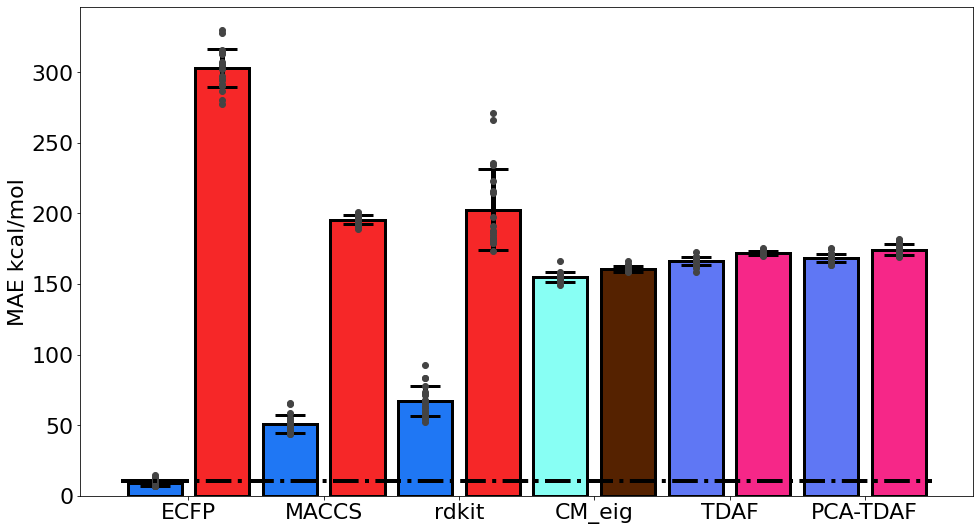

In [17]:


data=[output_metrics_ecfp['tr_mae'],
     output_metrics_ecfp['te_mae'],
     output_metrics_maccs['tr_mae'],
     output_metrics_maccs['te_mae'],
     output_metrics_rdkit['tr_mae'],
     output_metrics_rdkit['te_mae'],
     output_metrics_cm_eig['tr_mae'],
     output_metrics_cm_eig['te_mae'],
     output_metrics_tf['tr_mae'],
     output_metrics_tf['te_mae'],
     output_metrics_pca['tr_mae'],
     output_metrics_pca['te_mae']]
      
means=[np.mean(x) for x in data]
stds=[np.std(x) for x in data]


x_positions = [x+1 for x in range(len(means))]
plt.figure(figsize=(16, 9))
plt.rcParams.update({'font.size': 22})

plt.bar(x_positions, means, 
        color=["#1f77f4","#f62728",
               "#1f77f4","#f62728",
               "#1f77f4","#f62728",
               "#88fff4","#552200",
               "#5f77f4","#f62788",
               "#5f77f4","#f62788"], 
        edgecolor='k',
        linewidth='3',
        yerr=stds, 
        error_kw=dict(lw=5, capsize=15, capthick=3))
for i in range(len(means)):
    x=data[i]; plt.plot(np.ones(len(x))*(i+1),x,'o',color="#444444")

axes=plt.gca()
#axes.set_ylim([0.5,4.5])
#axes.set_xlim([0.45,4.55])
x_tick_list=[1.5,3.5,5.5,7.5,9.5,11.5]
plt.xticks(x_tick_list,['ECFP',"MACCS","rdkit","CM_eig","TDAF","PCA-TDAF"])
plt.plot([0.5,max(x_tick_list)+1],[best_con, best_con],'k',linewidth=4,linestyle='-.')
#plt.plot([0.5,max(x_tick_list)+1],[best_graph, best_graph],'g',linewidth=4,linestyle='-.')

plt.ylabel('MAE kcal/mol')
plt.savefig(os.path.join(dataset_name + "1Donly.png"))

## 2D inputs and graph models

In [ ]:
%%time
output_metrics_Sm2Img=h.deepchem_regression_experiment(
    metrics,
    metric_selector=selected_metric,
    dimension=2,
    feat_setting='Smiles2Img',
    model_setting='ChemCeption',
    loader=loaders[dataset_name],
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_function=Splitter,
    split_fraction=split_fraction,
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse'])

output_metrics_Sm2Img.head(3)

Metric selected is mae_score
Using dataset selector setting Smiles2Img
!!!!Make this function new for each new dataset!!!!
Training with 683 points
Validation with 683 points
Testing with 5464 points
Total dataset size: 6830
Step 15 validation: mae_score=0.796526
Step 30 validation: mae_score=0.795803
Step 45 validation: mae_score=0.795583
Step 60 validation: mae_score=0.799793
Step 75 validation: mae_score=0.81304
Step 90 validation: mae_score=0.842984
Step 105 validation: mae_score=0.895335
Step 120 validation: mae_score=0.908753
Step 135 validation: mae_score=0.924801
Step 150 validation: mae_score=0.92906
Step 165 validation: mae_score=0.934142
Step 180 validation: mae_score=0.917177
Step 195 validation: mae_score=0.91881
Step 210 validation: mae_score=0.915392
Step 225 validation: mae_score=0.937273
Step 240 validation: mae_score=0.911528
Step 255 validation: mae_score=0.918304
Step 270 validation: mae_score=0.913246
Step 285 validation: mae_score=0.924977
Step 300 validation: mae

In [19]:
%%time
output_metrics_gc=h.deepchem_regression_experiment(
    metrics,
    metric_selector=selected_metric,
    dimension=2,
    feat_setting='ConvMol',
    model_setting='GraphConv',
    loader=loaders[dataset_name],
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_function=Splitter,
    split_fraction=split_fraction,
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse'])

output_metrics_gc.head(3)

Metric selected is mae_score
Using dataset selector setting ConvMol
!!!!Make this function new for each new dataset!!!!
Training with 683 points
Validation with 683 points
Testing with 5464 points
Total dataset size: 6830
Using GraphConvMol model


C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model/graph_pool_1/Reshape_14:0", shape=(922,), dtype=int32), values=Tensor("gradient_tape/private__graph_conv_keras_model/graph_pool_1/Reshape_13:0", shape=(922, 64), dtype=float32), dense_shape=Tensor("gradient_tape/private__graph_conv_keras_model/graph_pool_1/Cast_4:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "shape. This may consume a large amount of memory." % value)
C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model/graph_pool_1/Reshape_17:0", shape=(228,), dtype=int32), values=Tensor("gradient_tape/private__gra

C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model/graph_pool/Reshape_17:0", shape=(228,), dtype=int32), values=Tensor("gradient_tape/private__graph_conv_keras_model/graph_pool/Reshape_16:0", shape=(228, 64), dtype=float32), dense_shape=Tensor("gradient_tape/private__graph_conv_keras_model/graph_pool/Cast_5:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "shape. This may consume a large amount of memory." % value)
C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model/graph_pool/Reshape_20:0", shape=(624,), dtype=int32), values=Tensor("gradient_tape/private__graph_conv_

C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model/graph_pool_1/Reshape_14:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/private__graph_conv_keras_model/graph_pool_1/Reshape_13:0", shape=(None, 64), dtype=float32), dense_shape=Tensor("gradient_tape/private__graph_conv_keras_model/graph_pool_1/Cast_4:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "shape. This may consume a large amount of memory." % value)
C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model/graph_pool_1/Reshape_17:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/private__

Step 15 validation: mae_score=0.849604
Step 30 validation: mae_score=0.923187
Step 45 validation: mae_score=1.06178
Step 60 validation: mae_score=1.14701
Step 75 validation: mae_score=1.23495
Step 90 validation: mae_score=1.14506
Step 105 validation: mae_score=1.11461
Step 120 validation: mae_score=1.06707
Step 135 validation: mae_score=1.06768
Step 150 validation: mae_score=1.03507
Step 165 validation: mae_score=1.0543
Step 180 validation: mae_score=1.00117
Step 195 validation: mae_score=0.968544
Step 210 validation: mae_score=0.966268
Step 225 validation: mae_score=0.929592
Step 240 validation: mae_score=0.921224
Step 255 validation: mae_score=0.913798
Step 270 validation: mae_score=0.869345
Step 285 validation: mae_score=0.872186
Step 300 validation: mae_score=0.877286
Step 315 validation: mae_score=0.887493
Step 330 validation: mae_score=0.920037
Step 345 validation: mae_score=0.865776
Step 360 validation: mae_score=0.896993
Step 375 validation: mae_score=0.883122
Step 390 validati

...

C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model_19/graph_pool_38/Reshape_14:0", shape=(935,), dtype=int32), values=Tensor("gradient_tape/private__graph_conv_keras_model_19/graph_pool_38/Reshape_13:0", shape=(935, 64), dtype=float32), dense_shape=Tensor("gradient_tape/private__graph_conv_keras_model_19/graph_pool_38/Cast_4:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "shape. This may consume a large amount of memory." % value)
C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model_19/graph_pool_38/Reshape_17:0", shape=(268,), dtype=int32), values=Tensor("gradient_t

C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model_19/graph_pool_39/Reshape_14:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/private__graph_conv_keras_model_19/graph_pool_39/Reshape_13:0", shape=(None, 64), dtype=float32), dense_shape=Tensor("gradient_tape/private__graph_conv_keras_model_19/graph_pool_39/Cast_4:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "shape. This may consume a large amount of memory." % value)
C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model_19/graph_pool_39/Reshape_20:0", shape=(None,), dtype=int32), values=Tensor("gradien

Step 15 validation: mae_score=0.859157
Step 30 validation: mae_score=0.85087
Step 45 validation: mae_score=0.845146
Step 60 validation: mae_score=0.873153
Step 75 validation: mae_score=0.929831
Step 90 validation: mae_score=0.902642
Step 105 validation: mae_score=0.955837
Step 120 validation: mae_score=0.912417
Step 135 validation: mae_score=0.888335
Step 150 validation: mae_score=0.862199
Step 165 validation: mae_score=0.909858
Step 180 validation: mae_score=0.919484
Step 195 validation: mae_score=0.931368
Step 210 validation: mae_score=0.910106
Step 225 validation: mae_score=0.863047
Step 240 validation: mae_score=0.866774
Step 255 validation: mae_score=0.880589
Step 270 validation: mae_score=0.919526
Step 285 validation: mae_score=0.875433
Step 300 validation: mae_score=0.866345
Step 315 validation: mae_score=0.849812
Step 330 validation: mae_score=0.867968
Step 345 validation: mae_score=0.878373
Step 360 validation: mae_score=0.885786
Step 375 validation: mae_score=0.871995
Step 39

Step 3060 validation: mae_score=0.867007
Step 3075 validation: mae_score=0.865616
Step 3090 validation: mae_score=0.864105
Step 3105 validation: mae_score=0.867486
Step 3120 validation: mae_score=0.865624
Step 3135 validation: mae_score=0.868165
Step 3150 validation: mae_score=0.865031
Step 3165 validation: mae_score=0.867143
Step 3180 validation: mae_score=0.867748
Step 3195 validation: mae_score=0.865613
Step 3210 validation: mae_score=0.860826
Step 3225 validation: mae_score=0.862769
Step 3240 validation: mae_score=0.861169
Step 3255 validation: mae_score=0.867359
Step 3270 validation: mae_score=0.862795
Step 3285 validation: mae_score=0.86078
Step 3300 validation: mae_score=0.860952
Step 3315 validation: mae_score=0.855454
Step 3330 validation: mae_score=0.861039
Step 3345 validation: mae_score=0.860874
Step 3360 validation: mae_score=0.857023
Step 3375 validation: mae_score=0.854329
Step 3390 validation: mae_score=0.856803
Step 3405 validation: mae_score=0.858285
Step 3420 validat

,tr_mse,tr_r2,tr_mae,tr_rmse,val_mse,val_r2,val_mae,val_rmse,te_mse,te_r2,te_mae,te_rmse
0,822.746539,0.983508,22.582112,28.683559,56177.055591,0.030024,186.856865,237.016994,58097.147928,0.019064,192.907772,241.033500
1,1066.809677,0.980638,25.604192,32.662053,56798.109955,0.039106,190.653197,238.323540,58259.633909,0.025674,192.102348,241.370325
2,722.483112,0.988464,21.577546,26.879046,60057.901866,0.008316,196.394182,245.067137,59299.766891,0.017493,193.164029,243.515435


In [ ]:
%%time
output_metrics_weave=h.deepchem_regression_experiment(
    metrics,
    metric_selector=selected_metric,
    dimension=2,
    feat_setting='Weave',
    model_setting='Weave',
    loader=loaders[dataset_name],
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_function=Splitter,
    split_fraction=split_fraction,
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse'])

output_metrics_weave.head(3)

In [21]:
%%time
output_metrics_cm=h.deepchem_regression_experiment(
    metrics,
    metric_selector=selected_metric,
    dimension=2,
    feat_setting='CM',
    model_setting='DTNN',
    loader=loaders[dataset_name],
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_function=Splitter,
    split_fraction=split_fraction,
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse'])

output_metrics_cm.head(3)

Metric selected is mae_score
Using dataset selector setting CM
!!!!Make this function new for each new dataset!!!!
Training with 683 points
Validation with 683 points
Testing with 5464 points
Total dataset size: 6830
Using DTNN model


C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/model_143/dtnn_step_1/Reshape_5:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/model_143/dtnn_step_1/Reshape_4:0", shape=(None, 60), dtype=float32), dense_shape=Tensor("gradient_tape/model_143/dtnn_step_1/Cast:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "shape. This may consume a large amount of memory." % value)
C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/model_143/dtnn_step/Reshape_5:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/model_143/dtnn_step/Reshape_4:0", shape=(None, 60), dtype=float32), dense_shape=Tensor("gradient_tape/model_

Step 15 validation: mae_score=0.773893
Step 30 validation: mae_score=0.768829
Step 45 validation: mae_score=0.767285
Step 60 validation: mae_score=0.757051
Step 75 validation: mae_score=0.786798
Step 90 validation: mae_score=0.761076
Step 105 validation: mae_score=0.774802
Step 120 validation: mae_score=0.779203
Step 135 validation: mae_score=0.772075
Step 150 validation: mae_score=0.791576
Step 165 validation: mae_score=0.811091
Step 180 validation: mae_score=0.804066
Step 195 validation: mae_score=0.787383
Step 210 validation: mae_score=0.807783
Step 225 validation: mae_score=0.817383
Step 240 validation: mae_score=0.844344
Step 255 validation: mae_score=0.839214
Step 270 validation: mae_score=0.858157
Step 285 validation: mae_score=0.86118
Step 300 validation: mae_score=0.885431
Step 315 validation: mae_score=0.883758
Step 330 validation: mae_score=0.911032
Step 345 validation: mae_score=0.918179
Step 360 validation: mae_score=0.935803
Step 375 validation: mae_score=0.948069
Step 39

Step 3120 validation: mae_score=1.1472
Step 3135 validation: mae_score=1.14472
Step 3150 validation: mae_score=1.14611
Step 3165 validation: mae_score=1.14604
Step 3180 validation: mae_score=1.1498
Step 3195 validation: mae_score=1.15198
Step 3210 validation: mae_score=1.1617
Step 3225 validation: mae_score=1.14043
Step 3240 validation: mae_score=1.13997
Step 3255 validation: mae_score=1.13765
Step 3270 validation: mae_score=1.14572
Step 3285 validation: mae_score=1.14518
Step 3300 validation: mae_score=1.14012
Step 3315 validation: mae_score=1.14559
Step 3330 validation: mae_score=1.14455
Step 3345 validation: mae_score=1.14263
Step 3360 validation: mae_score=1.14293
Step 3375 validation: mae_score=1.14763
Step 3390 validation: mae_score=1.14065
Step 3405 validation: mae_score=1.13875
Step 3420 validation: mae_score=1.14373
Step 3435 validation: mae_score=1.14839
Step 3450 validation: mae_score=1.14746
Step 3465 validation: mae_score=1.14726
Step 3480 validation: mae_score=1.14892
Ste

C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/model_144/dtnn_step_3/Reshape_5:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/model_144/dtnn_step_3/Reshape_4:0", shape=(None, 60), dtype=float32), dense_shape=Tensor("gradient_tape/model_144/dtnn_step_3/Cast:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "shape. This may consume a large amount of memory." % value)
C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/model_144/dtnn_step_2/Reshape_5:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/model_144/dtnn_step_2/Reshape_4:0", shape=(None, 60), dtype=float32), dense_shape=Tensor("gradient_tape/mo

...

Step 3105 validation: mae_score=1.07452
Step 3120 validation: mae_score=1.06847
Step 3135 validation: mae_score=1.06978
Step 3150 validation: mae_score=1.07152
Step 3165 validation: mae_score=1.07159
Step 3180 validation: mae_score=1.07003
Step 3195 validation: mae_score=1.07176
Step 3210 validation: mae_score=1.0678
Step 3225 validation: mae_score=1.06642
Step 3240 validation: mae_score=1.07005
Step 3255 validation: mae_score=1.06862
Step 3270 validation: mae_score=1.06609
Step 3285 validation: mae_score=1.06771
Step 3300 validation: mae_score=1.06431
Step 3315 validation: mae_score=1.05473
Step 3330 validation: mae_score=1.05906
Step 3345 validation: mae_score=1.06188
Step 3360 validation: mae_score=1.05834
Step 3375 validation: mae_score=1.06429
Step 3390 validation: mae_score=1.05547
Step 3405 validation: mae_score=1.05769
Step 3420 validation: mae_score=1.06266
Step 3435 validation: mae_score=1.0626
Step 3450 validation: mae_score=1.05227
Step 3465 validation: mae_score=1.0524
Ste

C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/model_162/dtnn_step_39/Reshape_5:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/model_162/dtnn_step_39/Reshape_4:0", shape=(None, 60), dtype=float32), dense_shape=Tensor("gradient_tape/model_162/dtnn_step_39/Cast:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "shape. This may consume a large amount of memory." % value)
C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/model_162/dtnn_step_38/Reshape_5:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/model_162/dtnn_step_38/Reshape_4:0", shape=(None, 60), dtype=float32), dense_shape=Tensor("gradient_ta

Step 15 validation: mae_score=0.789159
Step 30 validation: mae_score=0.782512
Step 45 validation: mae_score=0.769277
Step 60 validation: mae_score=0.766906
Step 75 validation: mae_score=0.769402
Step 90 validation: mae_score=0.766856
Step 105 validation: mae_score=0.761064
Step 120 validation: mae_score=0.759869
Step 135 validation: mae_score=0.763737
Step 150 validation: mae_score=0.767158
Step 165 validation: mae_score=0.781735
Step 180 validation: mae_score=0.784351
Step 195 validation: mae_score=0.796229
Step 210 validation: mae_score=0.806975
Step 225 validation: mae_score=0.797081
Step 240 validation: mae_score=0.810484
Step 255 validation: mae_score=0.824577
Step 270 validation: mae_score=0.82787
Step 285 validation: mae_score=0.841207
Step 300 validation: mae_score=0.870544
Step 315 validation: mae_score=0.864035
Step 330 validation: mae_score=0.890875
Step 345 validation: mae_score=0.886721
Step 360 validation: mae_score=0.89515
Step 375 validation: mae_score=0.914292
Step 390

Step 3075 validation: mae_score=1.005
Step 3090 validation: mae_score=1.00304
Step 3105 validation: mae_score=1.00373
Step 3120 validation: mae_score=1.00215
Step 3135 validation: mae_score=0.992568
Step 3150 validation: mae_score=1.00156
Step 3165 validation: mae_score=1.00155
Step 3180 validation: mae_score=1.00883
Step 3195 validation: mae_score=1.00633
Step 3210 validation: mae_score=1.00877
Step 3225 validation: mae_score=1.00778
Step 3240 validation: mae_score=0.996827
Step 3255 validation: mae_score=0.996521
Step 3270 validation: mae_score=1.00328
Step 3285 validation: mae_score=1.00379
Step 3300 validation: mae_score=1.00142
Step 3315 validation: mae_score=1.00199
Step 3330 validation: mae_score=0.995132
Step 3345 validation: mae_score=1.00256
Step 3360 validation: mae_score=1.0036
Step 3375 validation: mae_score=1.00295
Step 3390 validation: mae_score=1.00441
Step 3405 validation: mae_score=0.996902
Step 3420 validation: mae_score=0.995982
Step 3435 validation: mae_score=0.997

,tr_mse,tr_r2,tr_mae,tr_rmse,val_mse,val_r2,val_mae,val_rmse,te_mse,te_r2,te_mae,te_rmse
0,354.201364,0.992731,11.528722,18.820238,101146.299815,0.025705,256.294632,318.035061,97258.277550,0.034508,248.713707,311.862594
1,292.547403,0.994939,12.326036,17.104017,96259.903608,0.057055,243.846876,310.257802,99264.978156,0.032287,249.047403,315.063451
2,381.182197,0.992756,15.601760,19.523888,112027.214480,0.023053,258.338884,334.704668,111636.872767,0.039186,261.572487,334.121045


## Write out data and graphs

In [17]:
list_of_data_frames=[output_metrics_ecfp,
    output_metrics_maccs,
    output_metrics_rdkit,
    output_metrics_cm_eig,
    #output_metrics_Sm2Img,
    output_metrics_gc,
    #output_metrics_weave,
    output_metrics_cm,
    output_metrics_tf,
    output_metrics_pca]

list_of_data_frames_names=["output_metrics_ecfp",
    "output_metrics_maccs",
    "output_metrics_rdkit",
    "output_metrics_cm_eig",
    "output_metrics_Sm2Img",
    "output_metrics_gc",
    "output_metrics_weave",
    "output_metrics_cm",
    "output_metrics_tf",
    "output_metrics_pca"]



NameError: name 'output_metrics_ecfp' is not defined

In [58]:
color_list=["#1f77f4","#f62728", # red blue ecfp
                   "#1f77f4","#f62728", #maccs
                   "#1f77f4","#f62728", # rdkit
                   "#88fff4","#552200", #brown green # cmeig
                   "#61ff33","#ffb433", # green orange #sm2img
                   "#61ff33","#ffb433", # gc
                   "#61ff33","#ffb433",      #weave         
                   "#88fff4","#552200", #brown green    #cm           
                   "#5f77f4","#f62788", # pink blue tdaf
                   "#5f77f4","#f62788"] # pca-tdaf

missing_data = [4,6]

In [26]:
for i in range(len(list_of_data_frames)):
    list_of_data_frames[i].to_csv(os.path.join(
        results_dir, 
        list_of_data_frames_names[i] + '.csv'))


In [18]:
#Best=1.92
label1='val_mae'
label2='te_mae'

data=[output_metrics_ecfp[label1],
     output_metrics_ecfp[label2],
     output_metrics_maccs[label1],
     output_metrics_maccs[label2],
     output_metrics_rdkit[label1],
     output_metrics_rdkit[label2],
     output_metrics_cm_eig[label1],
     output_metrics_cm_eig[label2],
    # output_metrics_Sm2Img[label1],
    # output_metrics_Sm2Img['te_mae'],
     output_metrics_gc[label1],
     output_metrics_gc[label2],
   #  output_metrics_weave[label1],
   #  output_metrics_weave[label2],
     output_metrics_cm[label1],
     output_metrics_cm[label2],
     output_metrics_tf[label1],
     output_metrics_tf[label2],
     output_metrics_pca[label1],
     output_metrics_pca[label2]]
      
means=[np.mean(x) for x in data]
stds=[np.std(x) for x in data]


x_positions = [x+1 for x in range(len(means))]
plt.figure(figsize=(16, 9))
plt.rcParams.update({'font.size': 22})

plt.bar(x_positions, means, 
        color=["#1f77f4","#f62728", # red blue ecfp
               "#1f77f4","#f62728", #maccs
               "#1f77f4","#f62728", # rdkit
               "#88fff4","#552200", #brown green # cmeig
               "#61ff33","#ffb433", # green orange #sm2img
               "#61ff33","#ffb433", # gc
               "#61ff33","#ffb433",      #weave         
               "#88fff4","#552200", #brown green    #cm           
               "#5f77f4","#f62788", # pink blue tdaf
               "#5f77f4","#f62788"], # pca-tdaf
        edgecolor='k',
        linewidth='3',
        yerr=stds, 
        error_kw=dict(lw=5, capsize=15, capthick=3))
for i in range(len(means)):
    x=data[i]; plt.plot(np.ones(len(x))*(i+1),x,'o',color="#444444")


#axes.set_ylim([0.5,4.5])
#axes.set_xlim([0.45,4.55])
x_tick_list=[1.5,3.5,5.5,7.5,9.5,11.5,13.5,15.5,17.5,19.5]
label_list=['ECFP',
            "MACCS",
            "rdkit",
            "CM_eig",
            #'Sm2Img', 
            'GC', 
            #'Weave', 
            'CM',
            "TDAF",
            "PCA-TDAF"]
x_tick_list = x_tick_list[:len(label_list)]
plt.xticks(x_tick_list,
           label_list)

plt.plot([0.5,max(x_tick_list)+1],[best_con, best_con],'k',linewidth=4,linestyle='dashed')
plt.plot([0.5,max(x_tick_list)+1],[best_con+15, best_con+15],'grey',linewidth=4,linestyle='dotted')

plt.plot([0.5,max(x_tick_list)+1],[best_con-15, best_con-15],'grey',linewidth=4,linestyle='dotted')

plt.plot([0.5,max(x_tick_list)+1],[best_graph, best_graph],'g',linewidth=4,linestyle='-.')

axes=plt.gca()
plt.ylabel('MAE kcal/mol')
plt.savefig(os.path.join(results_dir, dataset_name + "all_data.png"))

NameError: name 'output_metrics_ecfp' is not defined

In [142]:
def method_comparison_plotter(
    list_of_data_frames,
    list_of_columns,
    color_list,
    exclusion_list = [],
    df_exclusion_list= [],
    label_list=[],
    best_con=None,
    best_con_error=None,
    best_gr=None,
    best_gr_error=None,
    x_label='',
    y_label='',
    filename='method_comparison',
    rider='all_data.png'):
    
    """Plotter
    list of data frames: list of results
    list_of_columns: which matrics to use (columsn in df)
    color_list = which colours to use
    exclusion_list: whether to miss out a df - either cos missing or unwanted
    df_exclusion_list: whether to miss out a column ONLY if not missing
    label_list: labels per dataset
    best_con: best 1D method
    best_con_error: std err
    best_gr: best graph method
    best_gr_error=None,
    x_label='',
    y_label='',
    filename='method_comparison',
    rider='all_data.png')"""
    
    #Best=1.92
    # pick subset of colours
    if color_list == None:
        color_list=["#1f77f4","#f62728", # red blue ecfp
                   "#1f77f4","#f62728", #maccs
                   "#1f77f4","#f62728", # rdkit
                   "#88fff4","#552200", #brown green # cmeig
                   "#61ff33","#ffb433", # green orange #sm2img
                   "#61ff33","#ffb433", # gc
                   "#61ff33","#ffb433",      #weave         
                   "#88fff4","#552200", #brown green    #cm           
                   "#5f77f4","#f62788", # pink blue tdaf
                   "#5f77f4","#f62788"] # pca-tdaf
    # get subset of labels
    if label_list == None:
            label_list=['ECFP',
                "MACCS",
                "rdkit",
                "CM_eig",
                'Sm2Img', 
                'GC', 
                'Weave', 
                'CM',
                "TDAF",
                "PCA-TDAF"]
    if exclusion_list:
        color_exclusion_list=[]
        for excluded in exclusion_list:
            for i in range(len(list_of_columns)):
                color_exclusion_list.append((excluded*len(list_of_columns))+i)
        print(color_exclusion_list)
        color_list = [color_list[i] for i in range(len(color_list)) if i not in color_exclusion_list]
        print(color_list)
        # subset of labels
        egg=[label_list[i] for i in range(len(label_list)) if i not in exclusion_list]
        label_list=egg

    data=[]
    for df_no in range(len(list_of_data_frames)):
        if df_no not in df_exclusion_list:
            df=list_of_data_frames[df_no]
            for col in list_of_columns:
                data.append(df[col])

    # calc and jot down the means
    print(len(data))
    means=[np.mean(x) for x in data]
    stds=[np.std(x) for x in data]
    egg= {'means': means, 'stds': stds}
    df2 = pd.DataFrame(egg) 
    # saving the dataframe 
    sigh=rider.split('.')[0]
    df2.to_csv(os.path.join(results_dir, 'means_stds_in_plot_' + filename + sigh + 'csv'))

    x_positions = [x+1 for x in range(len(means))]
    ax=plt.figure(figsize=(16, 9))
    plt.rcParams.update({'font.size': 22})

    plt.bar(x_positions, means, 
        color=color_list,
        edgecolor='k',
        linewidth='3',
        yerr=stds, 
        error_kw=dict(lw=5, capsize=15, capthick=3))

    for i in range(len(means)):
        x=data[i]; plt.plot(np.ones(len(x))*(i+1),x,'o',color="#444444")


    #axes.set_ylim([0.5,4.5])
    #axes.set_xlim([0.45,4.55])
    x_tick_list=[1.5,3.5,5.5,7.5,9.5,11.5,13.5,15.5,17.5,19.5]

    x_tick_list = x_tick_list[:len(label_list)]
    plt.xticks(x_tick_list,
               label_list)
    if best_con:
        plt.plot([0.5,max(x_tick_list)+1],[best_con, best_con],'k',linewidth=4,linestyle='dashed')
    
    if best_con_error:
        plt.plot([0.5,max(x_tick_list)+1],[best_con+best_con_error, best_con+best_con_error],'grey',linewidth=4,linestyle='dotted')
        plt.plot([0.5,max(x_tick_list)+1],[best_con-best_con_error, best_con-best_con_error],'grey',linewidth=4,linestyle='dotted')

    if best_gr:
        plt.plot([0.5,max(x_tick_list)+1],[best_con, best_con],'g',linewidth=4,linestyle='dashed')
    
    if best_gr_error:
        plt.plot([0.5,max(x_tick_list)+1],[best_con+best_con_error, best_con+best_con_error],'darkseagreen',linewidth=4,linestyle='dotted')
        plt.plot([0.5,max(x_tick_list)+1],[best_con-best_con_error, best_con-best_con_error],'darkseagreen',linewidth=4,linestyle='dotted')

    axes=plt.gca()
    plt.ylabel(y_label)
    plt.xlabel(x_label)
    plt.savefig(os.path.join(results_dir, filename + rider))
    return ax, means, stds

In [ ]:
ax, means, stds= method_comparison_plotter(
    list_of_data_frames=list_of_data_frames,
    list_of_columns=['val_mae','te_mae'],
    color_list=None,
    exclusion_list=[4,6],
    filename='method_comparison',
    label_list=['ECFP',
                "MACCS",
                "rdkit",
                "CM_eig",
                'Sm2Img', 
                'GC', 
                'Weave', 
                'CM',
                "TDAF",
                "PCA-TDAF"],
    best_con=best_con,
    best_con_error=15,
    best_gr=None,
    best_gr_error=None,
    x_label='',
    y_label='MAE kcal/mol',
    rider='all_data.png')
plt.title('QM7 Exp. 2 (10% training)')

In [ ]:
ax, means, stds= method_comparison_plotter(
    list_of_data_frames=list_of_data_frames,
    list_of_columns=['val_mae','te_mae'],
    color_list=None,
    exclusion_list=[4,5,6,7],
    df_exclusion_list=[5,7],
    filename='method_comparison',
    label_list=['ECFP',
                "MACCS",
                "rdkit",
                "CM_eig",
                'Sm2Img', 
                'GC', 
                'Weave', 
                'CM',
                "TDAF",
                "PCA-TDAF"],
    best_con=best_con,
    best_con_error=15,
    best_gr=None,
    best_gr_error=None,
    x_label='',
    y_label='MAE kcal/mol',
    rider='1D_data.png')
plt.title('QM7 Exp. 2 (10% training)')

In [96]:
df2 = pd.DataFrame(egg) 
df2

,means,stds
0,303.458493,14.722321
1,302.714286,13.687500
2,194.570750,6.794337
3,195.245401,3.156722
4,195.165498,44.070614
5,202.530359,28.771914
6,160.634106,2.894981
7,160.565497,1.928995
8,193.881910,3.696147
9,194.455206,2.091999


## if reloading cos you mucked up

In [57]:
        color_list=["#1f77f4","#f62728", # red blue ecfp
                   "#1f77f4","#f62728", #maccs
                   "#1f77f4","#f62728", # rdkit
                   "#88fff4","#552200", #brown green # cmeig
                   "#61ff33","#ffb433", # green orange #sm2img
                   "#61ff33","#ffb433", # gc
                   "#61ff33","#ffb433",      #weave         
                   "#88fff4","#552200", #brown green    #cm           
                   "#5f77f4","#f62788", # pink blue tdaf
                   "#5f77f4","#f62788"] # pca-tdaf
        if not exclusion_list == []:
            color_exclusion_list=[]
            for excluded in exclusion_list:
                for i in range(len(label_list)):
                    color_exclusion_list.append(excluded*no_of_labels -i)
            color_exclusion_list.sort()
            color_list = [x for x in color_list if x not in color_exclusion_list]
color_list

['#1f77f4',
 '#f62728',
 '#1f77f4',
 '#f62728',
 '#1f77f4',
 '#f62728',
 '#88fff4',
 '#552200',
 '#61ff33',
 '#ffb433',
 '#61ff33',
 '#ffb433',
 '#61ff33',
 '#ffb433',
 '#88fff4',
 '#552200',
 '#5f77f4',
 '#f62788',
 '#5f77f4',
 '#f62788']

In [22]:
list_of_filenames=["output_metrics_ecfp",
    "output_metrics_maccs",
    "output_metrics_rdkit",
    "output_metrics_cm_eig",
    "output_metrics_Sm2Img",
    "output_metrics_gc",
    "output_metrics_weave",
    "output_metrics_cm",
    "output_metrics_tf",
    "output_metrics_pca"]

exclusion_list = [4,6]
## copied over

def reload_experiment_dataframes(
    list_of_filenames,
    exclusion_list=[]):
    """reloads csv files into a list of dataframes"""

    list_of_dataframes= []
    for file_no in range(len(list_of_filenames)):
        if not file_no in exclusion_list:
            this_file = list_of_filenames[file_no] + '.csv'
            print(this_file)
            list_of_dataframes.append(
                pd.read_csv(
                    os.path.join(
                        results_dir,this_file)))
    return list_of_dataframes

list_of_data_frames=reload_experiment_dataframes(
    list_of_file_names, 
    exclusion_list)

output_metrics_ecfp.csv
output_metrics_maccs.csv
output_metrics_rdkit.csv
output_metrics_cm_eig.csv
output_metrics_gc.csv
output_metrics_cm.csv
output_metrics_tf.csv
output_metrics_pca.csv


In [16]:
list_of_dataframes

[    Unnamed: 0      tr_mse     tr_r2     tr_mae    tr_rmse        val_mse  \
 0            0  306.152183  0.994739   9.548321  17.497205  140802.161719   
 1            1  103.020668  0.998489   7.844089  10.149910  135387.381366   
 2            2   97.865202  0.998394   7.931589   9.892684  166468.407684   
 3            3  207.307707  0.996098   8.065214  14.398184  143732.289253   
 4            4   76.646762  0.998423   6.668446   8.754814  132899.314540   
 5            5  100.220331  0.998136   7.473367  10.011010  122428.864684   
 6            6  291.393050  0.998140  14.683113  17.070239  154980.616151   
 7            7  140.961592  0.998412   9.533587  11.872725  146235.535729   
 8            8  219.530868  0.995736   9.190476  14.816574  140240.786601   
 9            9  172.550625  0.996934   8.586518  13.135853  139203.653184   
 10          10   86.850687  0.998503   7.252388   9.319372  142809.241256   
 11          11   75.745409  0.998612   6.737298   8.703184  140

## stats stuff

import scipy
scipy.stats.ttest_ind(test_scores_CM_eig, test_scores_pca, axis=0, equal_var=True, nan_policy='propagate', alternative='two-sided')

In [ ]:
fh.close()